# Optimización de parámetros y experimentación de trading en ambos datasets

## Autor: Eloi Serantes Abal



Librerías empleadas:

In [ ]:
!pip install sumy pyarrow pandas tqdm nltk

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 41.0 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=e23e9d0895d68e0a94407e24ba0aa7ec514b1faeae44459363458b660cd5b3e6
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=def2f8ac73c00fe7eb84980f025713d89b87a8ae0c4f0a94e7a34150c0ee4478
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [ ]:
!pip install transformers torch tqdm pandas pyarrow

In [ ]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import nltk
from tqdm import tqdm

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words
from google.colab import drive

import pyarrow as pa
import zipfile
import gc
import time
from huggingface_hub import hf_hub_download
import requests
import io
import matplotlib.pyplot as plt
import warnings

import torch
from transformers import pipeline
from tqdm.auto import tqdm

import yfinance as yf
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import random
import time
import warnings
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

warnings.filterwarnings('ignore')

print("Conectando con Google Drive...")
drive.mount('/content/drive')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

tqdm.pandas()

Conectando con Google Drive...
Mounted at /content/drive


## Analisis de decaimiento según la fórmula y el valor de lambda usado

Primeramente se mira como afecta el valor de lambda al decaimiento de la tendencia de la noticia.

- ANÁLISIS TEÓRICO: DECAIMIENTO DEL SENTIMIENTO (λ = 0.03)

In [ ]:
def analizar_vida_util_noticia(lam=0.03, dias_max=160):
    print("="*75)
    print("ANÁLISIS TEÓRICO: DECAIMIENTO DEL SENTIMIENTO (λ = 0.03)")
    print("="*75)

    dias = np.arange(0, dias_max + 1)
    sentimiento = 1.0 * np.exp(-lam * dias)

    dia_mitad = np.argmax(sentimiento <= 0.5)
    dia_10_porciento = np.argmax(sentimiento <= 0.1)
    dia_1_porciento = np.argmax(sentimiento <= 0.01)

    print(f"Día 0: Impacto de la noticia al 100%")
    print(f"Día {dia_mitad}: El impacto se reduce a la mitad (Vida media).")
    print(f"Día {dia_10_porciento}: Solo queda un 10% del impacto original.")
    print(f"Día {dia_1_porciento}: Queda un 1% (Prácticamente desaparecido).")

    plt.figure(figsize=(10, 5))
    plt.plot(dias, sentimiento, color='blue', linewidth=2, label=r'$S(t) = S(0) \cdot e^{-0.1t}$')

    plt.axvline(x=dia_mitad, color='red', linestyle='--', alpha=0.7)
    plt.text(dia_mitad + 2, 0.5, f'50% (Día {dia_mitad})', color='red')

    plt.axvline(x=dia_10_porciento, color='orange', linestyle='--', alpha=0.7)
    plt.text(dia_10_porciento + 2, 0.1, f'10% (Día {dia_10_porciento})', color='orange')

    plt.axvline(x=dia_1_porciento, color='green', linestyle='--', alpha=0.7)
    plt.text(dia_1_porciento + 2, 0.05, f'1% (Día {dia_1_porciento})', color='green')

    plt.title('Curva de Decaimiento del Impacto de una Noticia Financiera', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Días transcurridos desde la noticia', fontsize=12)
    plt.ylabel('Fuerza del Sentimiento Residual', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

ANÁLISIS TEÓRICO: DECAIMIENTO DEL SENTIMIENTO (λ = 0.03)
Día 0: Impacto de la noticia al 100%
Día 24: El impacto se reduce a la mitad (Vida media).
Día 77: Solo queda un 10% del impacto original.
Día 154: Queda un 1% (Prácticamente desaparecido).


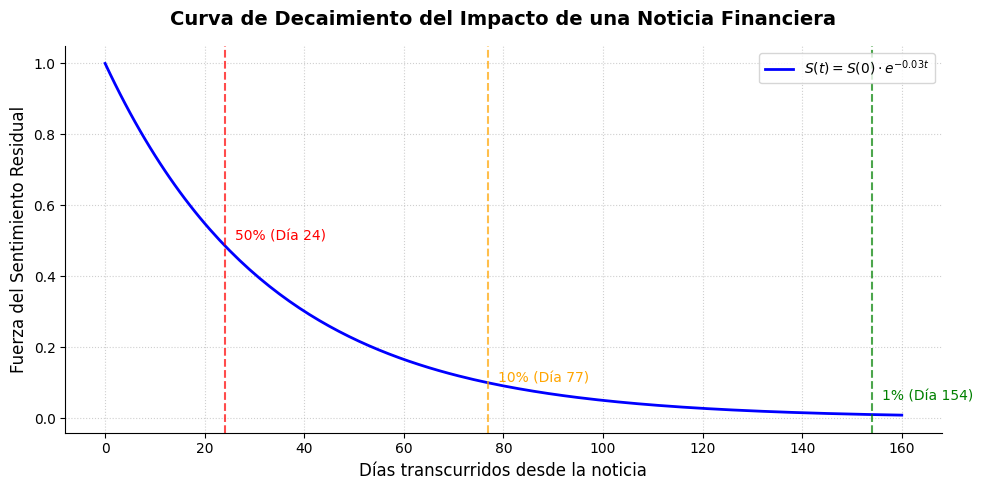

In [ ]:
analizar_vida_util_noticia()

- ANÁLISIS TEÓRICO: DECAIMIENTO DEL SENTIMIENTO (λ = 0.1)

ANÁLISIS TEÓRICO: DECAIMIENTO DEL SENTIMIENTO (λ = 0.1)
Día 0: Impacto de la noticia al 100%
Día 7: El impacto se reduce a la mitad (Vida media).
Día 24: Solo queda un 10% del impacto original.
Día 47: Queda un 1% (Prácticamente desaparecido).


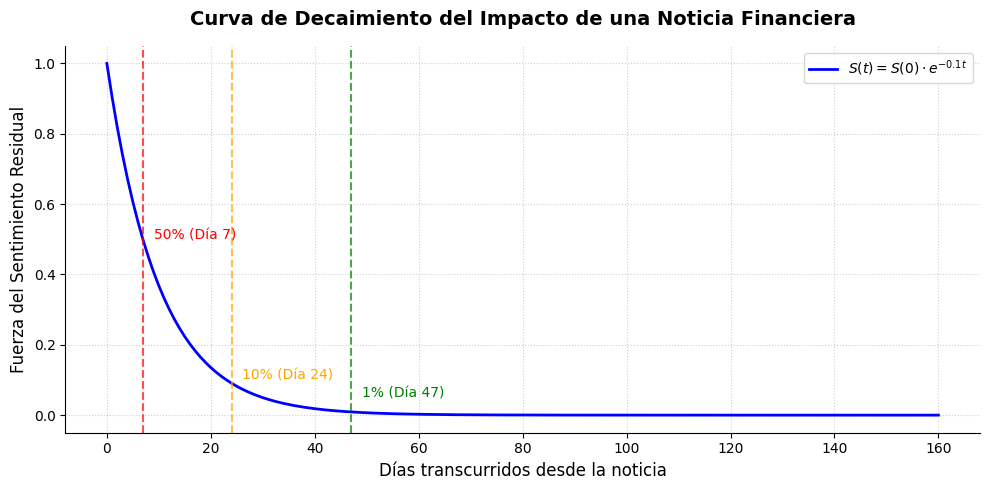

In [ ]:
analizar_vida_util_noticia(lam=0.1, dias_max=160)

### Grid Search del parámetro de lambda y tamaño de ventana para FinMultiTime

In [ ]:
def aplicar_decaimiento_dinamico(serie_diaria, lam):
    """Calcula el decaimiento al vuelo para cualquier lambda"""
    valores_finales = []
    ultimo_valor = 0
    dias_desde = 0
    for val in serie_diaria:
        if pd.notna(val):
            ultimo_valor = val
            dias_desde = 0
            valores_finales.append(val)
        else:
            dias_desde += 1
            valores_finales.append(ultimo_valor * np.exp(-lam * dias_desde))
    return valores_finales

In [ ]:
def experimento_ventanas_y_lambdas(ticker, ruta_sentimiento, ventanas=[5, 10, 15, 30], lambdas=[0.03, 0.1], n_runs=5):
    tiempo_inicio = time.time()

    print("="*75)
    print(f"ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA {ticker}")
    print("="*75)

    # CARGA DE DATOS
    df_precios_raw = yf.Ticker(ticker).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)
    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)
    df_sent = pd.read_parquet(ruta_sentimiento)
    df_sent = df_sent[df_sent['Stock_symbol'] == ticker].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    df_merged = df_precios.join(df_sent[['Daily_Sentiment']], how='inner').dropna(subset=['Log_Ret'])

    for lam in lambdas:
        df_merged[f'Sent_Decay_{lam}'] = aplicar_decaimiento_dinamico(df_merged['Daily_Sentiment'], lam)

    # ESCALADO
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])

    scalers_sent = {}
    for lam in lambdas:
        s = MinMaxScaler(feature_range=(-1, 1))
        df_merged[f'Sent_Scaled_{lam}'] = s.fit_transform(df_merged[[f'Sent_Decay_{lam}']])

    resultados_finales = []

    # BUCLE PRINCIPAL
    for w in ventanas:
        print(f"--- Evaluando Tamaño de Ventana: {w} días ---")

        r_vals = df_merged['Ret_Scaled'].values
        # Target direccional puro (1 si sube, 0 si baja)
        t_dir = (df_merged['Log_Ret'].values > 0).astype(int)

        X_hist = np.array([r_vals[i : i + w] for i in range(len(df_merged) - w)])
        X_hist = np.expand_dims(X_hist, axis=-1)
        y_dir_targ = np.array([t_dir[i + w] for i in range(len(df_merged) - w)])

        split = int(len(X_hist) * 0.8)
        X_train_h, X_test_h = X_hist[:split], X_hist[split:]
        y_train_dir, y_test_dir = y_dir_targ[:split], y_dir_targ[split:]

        dict_X_multi = {}
        for lam in lambdas:
            s_vals = df_merged[f'Sent_Scaled_{lam}'].values
            X_s = np.array([s_vals[i : i + w] for i in range(len(df_merged) - w)])
            X_m = np.stack((X_hist.squeeze(), X_s), axis=-1)
            dict_X_multi[lam] = (X_m[:split], X_m[split:])

        metrics_hist = {'Hit': [], 'AUC': []}
        metrics_multi = {lam: {'Hit': [], 'AUC': []} for lam in lambdas}

        for run in range(n_runs):
            tf.keras.backend.clear_session()
            np.random.seed(run)
            tf.random.set_seed(run)
            random.seed(run)

            def crear_modelo_clasificacion(input_shape):
                m = Sequential([
                    Input(shape=input_shape),
                    LSTM(50, return_sequences=True), Dropout(0.2),
                    LSTM(50, return_sequences=False), Dropout(0.2),
                    Dense(25),
                    Dense(1, activation='sigmoid')
                ])
                m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
                return m

            # Entrenar Histórico
            m_h = crear_modelo_clasificacion((w, 1))
            m_h.fit(X_train_h, y_train_dir, batch_size=32, epochs=15, verbose=0)
            pred_h_prob = m_h.predict(X_test_h, verbose=0).flatten()

            # Evaluación: Umbral 0.5 para Hit Ratio y Probabilidades para AUC
            pred_h_dir = (pred_h_prob > 0.5).astype(int)
            metrics_hist['Hit'].append(np.mean(pred_h_dir == y_test_dir) * 100)

            try:
                metrics_hist['AUC'].append(roc_auc_score(y_test_dir, pred_h_prob))
            except ValueError: # Captura el Model Collapse
                metrics_hist['AUC'].append(0.5)

            # Entrenar Multivariantes
            for lam in lambdas:
                X_train_m, X_test_m = dict_X_multi[lam]
                m_m = crear_modelo_clasificacion((w, 2))
                m_m.fit(X_train_m, y_train_dir, batch_size=32, epochs=15, verbose=0)
                pred_m_prob = m_m.predict(X_test_m, verbose=0).flatten()

                pred_m_dir = (pred_m_prob > 0.5).astype(int)
                metrics_multi[lam]['Hit'].append(np.mean(pred_m_dir == y_test_dir) * 100)

                try:
                    metrics_multi[lam]['AUC'].append(roc_auc_score(y_test_dir, pred_m_prob))
                except ValueError:
                    metrics_multi[lam]['AUC'].append(0.5)

        resultados_finales.append({'Ventana': w, 'Modelo': 'Solo Histórico',
                                   'Hit Ratio': np.mean(metrics_hist['Hit']),
                                   'AUC Score': np.mean(metrics_hist['AUC'])})

        for lam in lambdas:
            resultados_finales.append({'Ventana': w, 'Modelo': f'Histórico + Sent. (λ={lam})',
                                       'Hit Ratio': np.mean(metrics_multi[lam]['Hit']),
                                       'AUC Score': np.mean(metrics_multi[lam]['AUC'])})

    df_res = pd.DataFrame(resultados_finales)
    df_res['Ventana'] = df_res['Ventana'].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    paleta = ['#f47c7c', '#cce6ff', '#80bfff', '#1a75ff', '#003380'][:len(lambdas)+1]

    # Gráfico 1: Hit Ratio
    sns.barplot(data=df_res, x='Ventana', y='Hit Ratio', hue='Modelo', palette=paleta, ax=axes[0])
    axes[0].axhline(50, color='red', linestyle='--', label='Aleatorio (50%)')
    axes[0].set_title(f"Impacto del Tamaño de Ventana en Hit Ratio ({ticker})", fontweight='bold')
    axes[0].set_ylabel("Hit Ratio Medio (%)")
    min_hit = max(45, df_res['Hit Ratio'].min() - 2)
    max_hit = df_res['Hit Ratio'].max() + 2
    axes[0].set_ylim(min_hit, max_hit)
    axes[0].legend(title='Modelo')

    # Gráfico 2: AUC Score
    sns.lineplot(data=df_res, x='Ventana', y='AUC Score', hue='Modelo', palette=paleta, marker='o', linewidth=2, ax=axes[1])
    axes[1].axhline(0.50, color='black', linestyle=':', label='Azar (0.500)')
    axes[1].set_title(f"Impacto de la Ventana en la Capacidad Predictiva (AUC) - {ticker}", fontweight='bold')
    axes[1].set_ylabel("AUC Score Medio")
    axes[1].legend(title='Modelo')

    plt.tight_layout()
    plt.show()

    return df_res

- APPLE

ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA AAPL
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


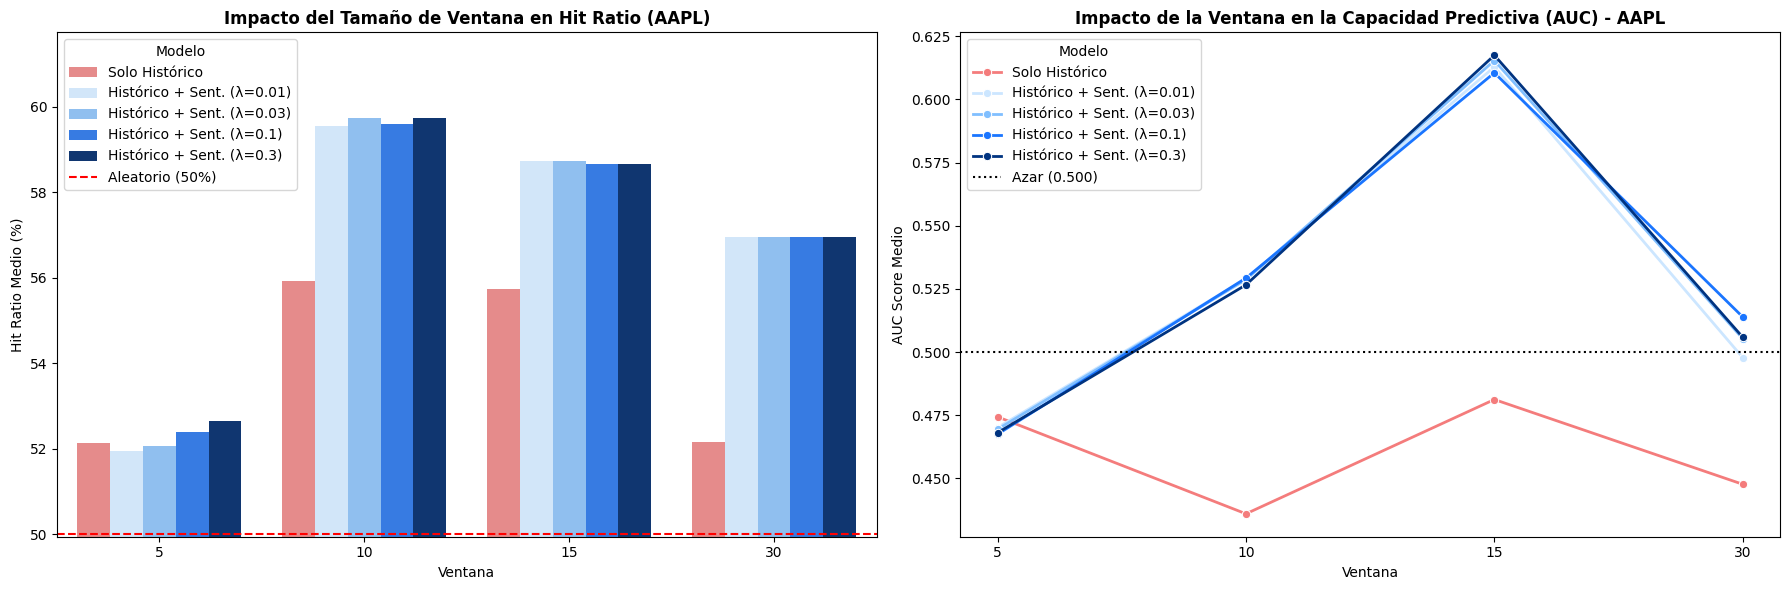

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='AAPL',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

- NVIDIA

ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA NVDA
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


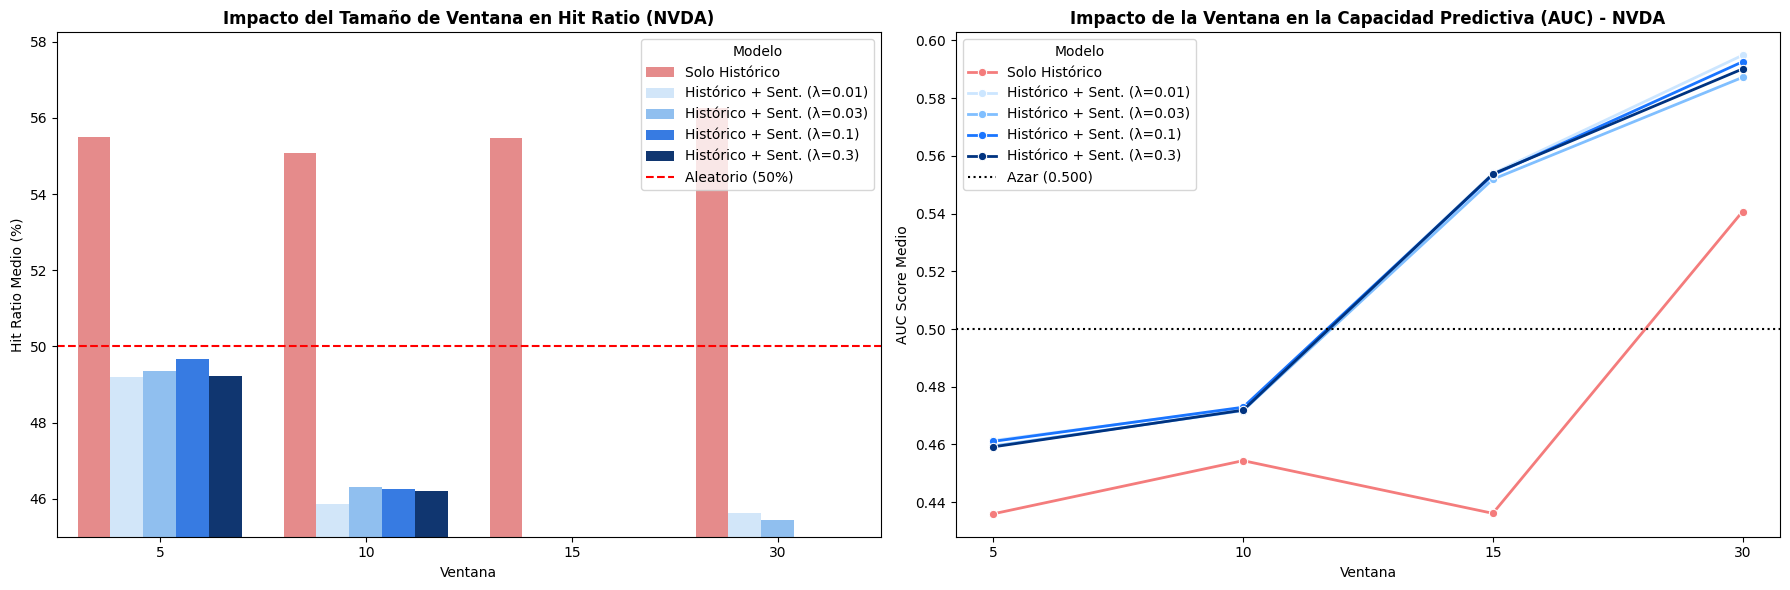

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='NVDA',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

- ORACLE

ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA ORCL
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


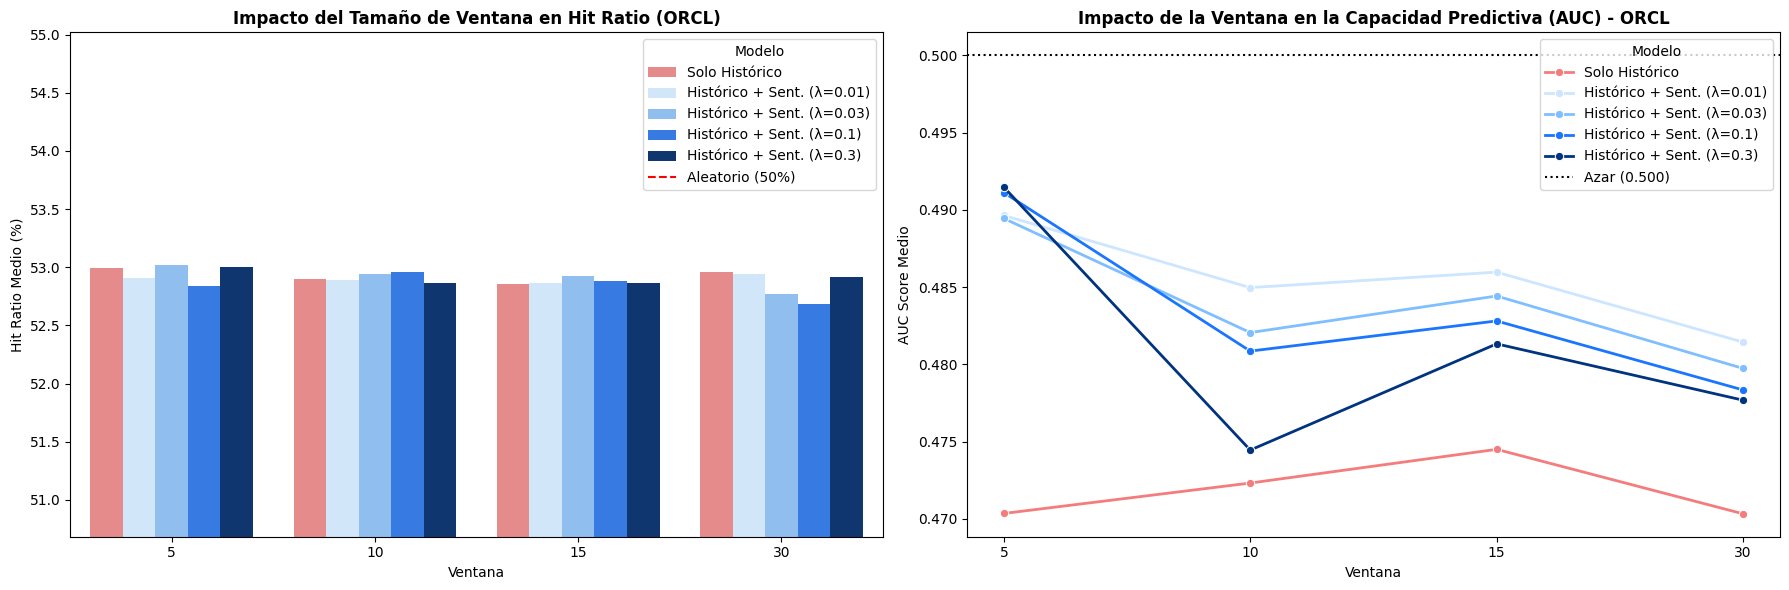

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='ORCL',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

Se guarda un dataset con lambda 0.1

In [ ]:
def generar_dataset_decaimiento(ruta_entrada, ruta_salida, lam=0.1):
    """
    Función para aplicar decaimiento exponencial a cualquier dataset de FinBERT.
    """
    print("="*75)
    print(f"GENERANDO DATASET CON DECAIMIENTO (λ = {lam})")
    print(f"Entrada: {ruta_entrada.split('/')[-1]}")
    print("="*75)

    try:
        # Cargar datos
        print("Cargando dataset original...")
        df = pd.read_parquet(ruta_entrada)

        if 'Sentiment_Label' in df.columns:
            col_label, col_score = 'Sentiment_Label', 'Sentiment_Score'
        elif 'Summary_Sentiment' in df.columns:
            col_label, col_score = 'Summary_Sentiment', 'Summary_Score'
        else:
            raise KeyError("No se detectaron las columnas de sentimiento de FinBERT en el dataset.")

        # Polarización a escala
        print("Calculando Vector Continuo de Sentimiento (-1.0 a 1.0)...")
        mapeo = {'positive': 1, 'neutral': 0, 'negative': -1}
        df['Sentiment_Discrete'] = df[col_label].map(mapeo)
        df['Sentiment_Continuous'] = df['Sentiment_Discrete'] * df[col_score]

        # Media diaria
        print("Agrupando noticias por empresa y colapsando a medias diarias...")
        df['Date_Only'] = pd.to_datetime(df['Date']).dt.date
        df_diario = df.groupby(['Stock_symbol', 'Date_Only'])['Sentiment_Continuous'].mean().reset_index()
        df_diario = df_diario.rename(columns={'Sentiment_Continuous': 'Daily_Sentiment'})
        df_diario['Date_Only'] = pd.to_datetime(df_diario['Date_Only'])

        # Rellenar huecos y aplicar la fórmula
        print(f"Rellenando vacíos informativos y aplicando decaimiento (λ = {lam})...")
        resultados = []

        # Procesamos empresa por empresa
        for ticker, grupo in df_diario.groupby('Stock_symbol'):
            fecha_min = grupo['Date_Only'].min()
            fecha_max = grupo['Date_Only'].max()
            rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')

            grupo = grupo.set_index('Date_Only').reindex(rango_fechas).rename_axis('Date_Only').reset_index()
            grupo['Stock_symbol'] = ticker

            valores_finales = []
            ultimo_valor = 0
            dias_desde_noticia = 0

            for valor_actual in grupo['Daily_Sentiment']:
                if pd.notna(valor_actual):
                    ultimo_valor = valor_actual
                    dias_desde_noticia = 0
                    valores_finales.append(valor_actual)
                else:
                    dias_desde_noticia += 1
                    valor_decaimiento = ultimo_valor * np.exp(-lam * dias_desde_noticia)
                    valores_finales.append(valor_decaimiento)

            grupo['Sentiment_Paper_Decay'] = valores_finales
            resultados.append(grupo)

        df_final = pd.concat(resultados, ignore_index=True)

        print("Guardando archivo final...")
        df_final.to_parquet(ruta_salida, index=False)

        print("\n" + "="*75)
        print(f"¡Dataset generado con éxito!")
        print(f"Ruta: {ruta_salida}")
        print("="*75)

        return df_final

    except Exception as e:
        print(f"Error crítico: {e}")
        return None

In [ ]:
entrada_finn = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_FinBERT_Sentiments.parquet'
salida_finn = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM_lam01.parquet'

entrada_fnspid = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'
salida_fnspid = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM_lam01.parquet'

generar_dataset_decaimiento(ruta_entrada=entrada_finn, ruta_salida=salida_finn, lam=0.1)

generar_dataset_decaimiento(ruta_entrada=entrada_fnspid, ruta_salida=salida_fnspid, lam=0.1)

GENERANDO DATASET CON DECAIMIENTO (λ = 0.1)
Entrada: FinnMultiTime_FinBERT_Sentiments.parquet
1. Cargando dataset original...
2. Calculando Vector Continuo de Sentimiento (-1.0 a 1.0)...
3. Agrupando noticias por empresa y colapsando a medias diarias...
4. Rellenando vacíos informativos y aplicando decaimiento (λ = 0.1)...
5. Guardando archivo final...

¡Dataset generado con éxito!
Ruta: /content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM_lam01.parquet
GENERANDO DATASET CON DECAIMIENTO (λ = 0.1)
Entrada: fnspid_finbert_titulares_resumenes.parquet
1. Cargando dataset original...
2. Calculando Vector Continuo de Sentimiento (-1.0 a 1.0)...
3. Agrupando noticias por empresa y colapsando a medias diarias...
4. Rellenando vacíos informativos y aplicando decaimiento (λ = 0.1)...
5. Guardando archivo final...

¡Dataset generado con éxito!
Ruta: /content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM_lam01.parquet


,Date_Only,Stock_symbol,Daily_Sentiment,Sentiment_Paper_Decay
0,2022-09-11,A,0.000000,0.000000
1,2022-09-12,A,NaN,0.000000
2,2022-09-13,A,NaN,0.000000
3,2022-09-14,A,NaN,0.000000
4,2022-09-15,A,0.953759,0.953759
...,...,...,...,...
1439596,2023-12-08,ZTS,0.858525,0.858525
1439597,2023-12-09,ZTS,NaN,0.776826
1439598,2023-12-10,ZTS,0.000000,0.000000
1439599,2023-12-11,ZTS,0.071972,0.071972


## Experimentación de trading con los distintos parámetros óptimos conseguidos en el Grid Search

### Cargamos el modelo final

In [ ]:
def experimento_clasificacion_direcional(
    ticker_elegido,
    ruta_sentimiento,
    n_runs=100,
    window_size=10
):
    # Registro del tiempo para medir el coste computacional del experimento
    tiempo_inicio = time.time()
    TICKER = ticker_elegido

    print("="*80)
    print(f"INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA {TICKER}")
    print("="*80)

    # =========================================================================
    # 1. PREPARACIÓN DE DATOS (PRECIOS Y SENTIMIENTO)
    # =========================================================================
    # Extracción de datos históricos usando la API de Yahoo Finance
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()

    # Estandarización del índice temporal: eliminación de zonas horarias para evitar
    # desajustes en el cruce (merge) posterior con el dataset de sentimiento
    if df_precios.index.tz is not None:
        df_precios.index = df_precios.index.tz_localize(None)

    df_precios.index = pd.to_datetime(df_precios.index.date)

    # Cálculo de retornos logarítmicos: estándar en econometría financiera por
    # sus propiedades aditivas y por mejorar la estacionariedad de la serie
    df_precios['Log_Ret'] = np.log(
        df_precios['Close'] / df_precios['Close'].shift(1)
    )

    df_precios.dropna(inplace=True)

    # Variable dependiente (Target): 1 si el precio sube (retorno > 0), 0 si baja o se mantiene
    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    # Carga eficiente de la base de datos de sentimiento (formato Parquet)
    df_sent = pd.read_parquet(ruta_sentimiento)

    # Filtrado por el activo de interés y normalización de fechas
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only']).dt.normalize()
    df_sent.set_index('Date_Only', inplace=True)

    # Intersección de ambos conjuntos de datos (Inner Join) asegurando que
    # solo se conserven los días donde existen tanto datos de mercado como de sentimiento
    df_merged = df_precios.join(
        df_sent[['Sentiment_Paper_Decay']],
        how='inner'
    ).dropna()

    def crear_ventanas_raw(df, window):
        """
        Genera secuencias temporales (ventanas deslizantes) para alimentar la red LSTM.
        Crea las ventanas ANTES de escalar para evitar Data Leakage (fuga de información).
        """

        X_r, X_s, y_dir, y_ret = [], [], [], []

        r_vals = df['Log_Ret'].values
        s_vals = df['Sentiment_Paper_Decay'].values
        t_dir = df['Target_Dir'].values
        t_ret = df['Log_Ret'].values

        # Desplazamiento iterativo: se toman 'window' días como variables independientes (X)
        # para predecir el día inmediatamente posterior (y)
        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y_dir.append(t_dir[i + window])
            y_ret.append(t_ret[i + window])

        return (
            np.array(X_r),
            np.array(X_s),
            np.array(y_dir),
            np.array(y_ret)
        )

    # Generación de la estructura tensorial de características y etiquetas
    X_ret_raw, X_sent_raw, y_targets_dir, y_targets_ret = crear_ventanas_raw(
        df_merged,
        window_size
    )

    # División cronológica del conjunto de datos (Hold-out): 80% Train, 20% Test
    split = int(len(X_ret_raw) * 0.8)

    # =========================================================================
    # 2. ESCALADO DE DATOS (PREVENCIÓN DE DATA LEAKAGE)
    # =========================================================================
    # Se normalizan los datos al rango [-1, 1] para facilitar la convergencia de la red LSTM
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    # El scaler se ajusta (fit) ÚNICAMENTE con los datos de entrenamiento
    X_ret_train_scaled = scaler_retorno.fit_transform(
        X_ret_raw[:split].reshape(-1, 1)
    ).reshape(-1, window_size)

    # Los datos de test se transforman usando los parámetros aprendidos en train
    X_ret_test_scaled = scaler_retorno.transform(
        X_ret_raw[split:].reshape(-1, 1)
    ).reshape(-1, window_size)

    X_sent_train_scaled = scaler_sent.fit_transform(
        X_sent_raw[:split].reshape(-1, 1)
    ).reshape(-1, window_size)

    X_sent_test_scaled = scaler_sent.transform(
        X_sent_raw[split:].reshape(-1, 1)
    ).reshape(-1, window_size)

    # Formateo de dimensiones (Samples, Time Steps, Features) exigido por Keras para capas recurrentes
    # Modelo Univariante: Solo retornos (1 feature)
    X_train_u = np.expand_dims(X_ret_train_scaled, axis=-1)
    X_test_u = np.expand_dims(X_ret_test_scaled, axis=-1)

    # Modelo Multivariante: Retornos + Sentimiento (2 features)
    X_train_m = np.stack(
        (X_ret_train_scaled, X_sent_train_scaled),
        axis=-1
    )

    X_test_m = np.stack(
        (X_ret_test_scaled, X_sent_test_scaled),
        axis=-1
    )

    y_train_dir, y_test_dir = (
        y_targets_dir[:split],
        y_targets_dir[split:]
    )

    # Se conserva el retorno real en test para simular posteriormente la curva de capital
    y_test_ret = y_targets_ret[split:]

    # =========================================================================
    # 3. BUCLE DE EXPERIMENTOS (ESTUDIO DE ROBUSTEZ)
    # =========================================================================
    # Las Redes Neuronales son estocásticas. Se iteran 'n_runs' veces para obtener
    # una distribución de resultados y evitar sesgos por la inicialización de los pesos.
    lista_acc_uni, lista_acc_multi = [], []

    lista_f1_uni, lista_f1_multi = [], []
    lista_rec_uni, lista_rec_multi = [], []
    lista_prec_uni, lista_prec_multi = [], []

    lista_auc_uni, lista_auc_multi = [], []
    cm_uni_total = np.zeros((2, 2))
    cm_multi_total = np.zeros((2, 2))

    curvas_cap_lo_uni, curvas_cap_lo_multi = [], []
    curvas_cap_ls_uni, curvas_cap_ls_multi = [], []

    for i in range(n_runs):

        # Liberación de memoria de modelos previos para evitar sobrecarga (OOM) en el bucle
        tf.keras.backend.clear_session()

        # Fijación de semillas (seeds) para garantizar la reproducibilidad de cada iteración
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_clasificacion(input_shape):
            """Define la arquitectura Deep Learning basada en capas LSTM."""
            m = Sequential([
                Input(shape=input_shape),
                # Capa recurrente para extraer patrones secuenciales complejos
                LSTM(50, return_sequences=True),
                # Regularización mediante Dropout (20%) para mitigar el sobreajuste (overfitting)
                Dropout(0.2),
                LSTM(50, return_sequences=False),
                Dropout(0.2),
                # Capa densa de abstracción final
                Dense(25),
                # Capa de salida con activación Sigmoide (ideal para clasificación binaria)
                Dense(1, activation='sigmoid')
            ])

            # Compilación usando Adam (optimización adaptativa) e entropía cruzada binaria
            m.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            return m

        # Callback Early Stopping: Detiene el entrenamiento si el loss de validación no mejora,
        # restaurando los mejores pesos encontrados para prevenir la degradación del modelo.
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=0
        )

        # Entrenamiento de la red Univariante
        m_uni = crear_modelo_clasificacion((window_size, 1))
        m_uni.fit(
            X_train_u, y_train_dir,
            batch_size=32, epochs=30,
            validation_split=0.1, callbacks=[early_stop], verbose=0
        )

        # Entrenamiento de la red Multivariante
        m_multi = crear_modelo_clasificacion((window_size, 2))
        m_multi.fit(
            X_train_m, y_train_dir,
            batch_size=32, epochs=30,
            validation_split=0.1, callbacks=[early_stop], verbose=0
        )

        # Inferencia: Probabilidades continuas predichas [0, 1]
        p_u_prob = m_uni.predict(X_test_u, verbose=0).flatten()
        p_m_prob = m_multi.predict(X_test_m, verbose=0).flatten()

        # Binarización de probabilidades usando un umbral de 0.5 (Clasificación dura)
        p_u_class = (p_u_prob > 0.5).astype(int)
        p_m_class = (p_m_prob > 0.5).astype(int)

        # Evaluación: Capacidad de discriminación global del modelo (Área bajo la curva ROC)
        try:
            lista_auc_uni.append(roc_auc_score(y_test_dir, p_u_prob))
        except ValueError:
            lista_auc_uni.append(0.5)

        try:
            lista_auc_multi.append(roc_auc_score(y_test_dir, p_m_prob))
        except ValueError:
            lista_auc_multi.append(0.5)

        # Acumulación de las matrices de confusión para calcular la matriz promedio al final
        cm_uni_total += confusion_matrix(y_test_dir, p_u_class, labels=[0, 1])
        cm_multi_total += confusion_matrix(y_test_dir, p_m_class, labels=[0, 1])

        # Métricas de rendimiento de Machine Learning
        # Accuracy: Porcentaje de aciertos totales
        lista_acc_uni.append(np.mean(p_u_class == y_test_dir) * 100)
        lista_acc_multi.append(np.mean(p_m_class == y_test_dir) * 100)

        # Precision (calidad de positivos), Recall (sensibilidad) y F1-Score (media armónica)
        lista_prec_uni.append(precision_score(y_test_dir, p_u_class, zero_division=0) * 100)
        lista_rec_uni.append(recall_score(y_test_dir, p_u_class, zero_division=0) * 100)
        lista_f1_uni.append(f1_score(y_test_dir, p_u_class, zero_division=0) * 100)

        lista_prec_multi.append(precision_score(y_test_dir, p_m_class, zero_division=0) * 100)
        lista_rec_multi.append(recall_score(y_test_dir, p_m_class, zero_division=0) * 100)
        lista_f1_multi.append(f1_score(y_test_dir, p_m_class, zero_division=0) * 100)

        # =========================================================================
        # 4. SIMULACIÓN DE ESTRATEGIAS FINANCIERAS (BACKTESTING)
        # =========================================================================
        # Estrategia Long-Only: Se invierte solo cuando la predicción es alcista (1).
        # Si predice bajada (0), se queda fuera del mercado (retorno 0).
        curvas_cap_lo_uni.append(np.cumsum(p_u_class * y_test_ret))
        curvas_cap_lo_multi.append(np.cumsum(p_m_class * y_test_ret))

        # Estrategia Long/Short: Posición larga (1) si predice subida, corta (-1) si predice bajada.
        senal_ls_uni = np.where(p_u_class == 1, 1, -1)
        senal_ls_multi = np.where(p_m_class == 1, 1, -1)

        curvas_cap_ls_uni.append(np.cumsum(senal_ls_uni * y_test_ret))
        curvas_cap_ls_multi.append(np.cumsum(senal_ls_multi * y_test_ret))

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")


    # =========================================================================
    # 5. CÁLCULO DE MÉTRICAS FINANCIERAS DE RIESGO-RETORNO
    # =========================================================================
    def calcular_sharpe(curvas, trading_days=252):
        """Calcula el Ratio de Sharpe Anualizado (asumiendo tasa libre de riesgo = 0)"""
        sharpes = []
        for curva in curvas:
            retornos_diarios = np.diff(curva, prepend=0)
            if retornos_diarios.std() == 0:
                sharpes.append(0)
            else:
                sharpes.append((retornos_diarios.mean() / retornos_diarios.std()) * np.sqrt(trading_days))
        return np.mean(sharpes)

    def calcular_max_drawdown(curvas):
        """Calcula la máxima caída acumulada (riesgo extremo) desde un pico previo"""
        drawdowns = []
        for curva in curvas:
            picos = np.maximum.accumulate(curva)
            caidas = curva - picos
            drawdowns.append(caidas.min() * 100)
        return np.mean(drawdowns)

    # Evaluación financiera comparativa de las estrategias
    sr_lo_uni = calcular_sharpe(curvas_cap_lo_uni)
    sr_lo_multi = calcular_sharpe(curvas_cap_lo_multi)
    sr_ls_uni = calcular_sharpe(curvas_cap_ls_uni)
    sr_ls_multi = calcular_sharpe(curvas_cap_ls_multi)

    mdd_lo_uni = calcular_max_drawdown(curvas_cap_lo_uni)
    mdd_lo_multi = calcular_max_drawdown(curvas_cap_lo_multi)
    mdd_ls_uni = calcular_max_drawdown(curvas_cap_ls_uni)
    mdd_ls_multi = calcular_max_drawdown(curvas_cap_ls_multi)

    # Benchmark: Estrategia pasiva del mercado (Comprar y Mantener / Buy & Hold)
    mercado_acumulado = np.cumsum(y_test_ret)
    sr_bh = (
        (y_test_ret.mean() / y_test_ret.std()) * np.sqrt(252)
        if y_test_ret.std() != 0 else 0
    )
    mdd_bh = (mercado_acumulado - np.maximum.accumulate(mercado_acumulado)).min() * 100

    # =========================================================================
    # 6. PRESENTACIÓN DE RESULTADOS POR CONSOLA
    # =========================================================================
    tiempo_total = time.time() - tiempo_inicio

    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    # Tabla 1: Métricas Predictivas
    print("\n" + "="*80)
    print("RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)")
    print("="*80)
    print(f"{'Modelo':<28} | {'Hit Ratio':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
    print("-" * 80)
    print(f"{'Univariante (Solo Hist.)':<28} | {np.mean(lista_acc_uni):>9.2f}% | {np.mean(lista_prec_uni):>9.2f}% | {np.mean(lista_rec_uni):>9.2f}% | {np.mean(lista_f1_uni):>9.2f}%")
    print(f"{'Multivariante (Hist + Sent)':<28} | {np.mean(lista_acc_multi):>9.2f}% | {np.mean(lista_prec_multi):>9.2f}% | {np.mean(lista_rec_multi):>9.2f}% | {np.mean(lista_f1_multi):>9.2f}%")

    # Tabla 2: Métricas Financieras
    print("\n" + "="*80)
    print("RESUMEN DE MÉTRICAS FINANCIERAS")
    print("="*80)
    print(f"{'Estrategia / Modelo':<35} | {'Sharpe Ratio':>15} | {'Max Drawdown':>15}")
    print("-" * 80)
    print(f"{'Buy & Hold (Mercado)':<35} | {sr_bh:>15.3f} | {mdd_bh:>14.2f}%")
    print(f"{'Long-Only Univariante':<35} | {sr_lo_uni:>15.3f} | {mdd_lo_uni:>14.2f}%")
    print(f"{'Long-Only Multivariante':<35} | {sr_lo_multi:>15.3f} | {mdd_lo_multi:>14.2f}%")
    print(f"{'Long/Short Univariante':<35} | {sr_ls_uni:>15.3f} | {mdd_ls_uni:>14.2f}%")
    print(f"{'Long/Short Multivariante':<35} | {sr_ls_multi:>15.3f} | {mdd_ls_multi:>14.2f}%")
    print("="*80)

    # =========================================================================
    # 7. VISUALIZACIÓN DE RENDIMIENTO Y CURVAS DE CAPITAL
    # =========================================================================
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    fig.suptitle(f"Estudio de Clasificación Direccional — {TICKER}", fontsize=16, fontweight='bold', y=1.01)

    # Panel 1: Función de Densidad (KDE) para observar la estabilidad del Accuracy en las N iteraciones
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='Solo Histórico', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='Histórico + Sentimiento', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio en {n_runs} iteraciones", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].legend()

    # Panel 2: Comparativa directa con barras de error para evaluar significancia estadística
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Líder de Clasificación Direccional", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    # Panel 3: Evolución patrimonial (Curvas de Capital) comparando con Benchmark
    media_cap_ls_uni = np.mean(curvas_cap_ls_uni, axis=0) * 100
    media_cap_ls_multi = np.mean(curvas_cap_ls_multi, axis=0) * 100
    mercado_acumulado_pct = mercado_acumulado * 100
    eje_x = range(len(mercado_acumulado_pct))

    axes[2].plot(eje_x, mercado_acumulado_pct, label=f"Mercado (Buy & Hold) | Sharpe: {sr_bh:.2f}", color='black', linewidth=2)
    axes[2].plot(eje_x, media_cap_ls_uni, label=f"Long/Short: Solo Histórico | Sharpe: {sr_ls_uni:.2f}", color='red', linestyle='--')
    axes[2].plot(eje_x, media_cap_ls_multi, label=f"Long/Short: Hist. + Sent. | Sharpe: {sr_ls_multi:.2f}", color='blue', linewidth=2)

    axes[2].set_title("Simulación de Inversión (Long/Short): Retorno Acumulado", fontweight='bold')
    axes[2].set_ylabel("Retorno Acumulado (%)")
    axes[2].set_xlabel("Días de Trading en el Conjunto de Test")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 8. DIAGNÓSTICO PROFUNDO DEL MODELO (MATRICES Y ROC)
    # =========================================================================
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    fig2.suptitle("Diagnóstico del Modelo: Capacidad Predictiva Real", fontsize=16, fontweight='bold', y=1.05)

    # GRÁFICO 1: Curvas ROC-AUC (Evalúa el balance entre Verdaderos y Falsos Positivos a distintos umbrales)
    fpr_u, tpr_u, _ = roc_curve(y_test_dir, p_u_prob)
    fpr_m, tpr_m, _ = roc_curve(y_test_dir, p_m_prob)

    axes2[0].plot(fpr_u, tpr_u, color='red', linestyle='--', label=f'Solo Histórico (AUC prom: {np.mean(lista_auc_uni):.3f})')
    axes2[0].plot(fpr_m, tpr_m, color='blue', linewidth=2, label=f'Histórico + Sent. (AUC prom: {np.mean(lista_auc_multi):.3f})')
    axes2[0].plot([0, 1], [0, 1], color='black', linestyle=':', label='Azar (AUC: 0.500)')
    axes2[0].set_title("Curva ROC", fontweight='bold')
    axes2[0].set_xlabel("Tasa de Falsos Positivos (FPR)")
    axes2[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)

    # GRÁFICO 2: Matriz de Confusión Univariante Promediada (Muestra falsos positivos, falsos negativos, etc.)
    cm_uni_avg = cm_uni_total / n_runs
    sns.heatmap(cm_uni_avg, annot=True, fmt=".1f", cmap="Reds", ax=axes2[1], cbar=False,
                xticklabels=['Baja (0)', 'Sube (1)'], yticklabels=['Baja (0)', 'Sube (1)'])
    axes2[1].set_title("Matriz de Confusión: Solo Histórico", fontweight='bold')
    axes2[1].set_ylabel("Realidad (Mercado)")
    axes2[1].set_xlabel("Predicción del Modelo")

    # GRÁFICO 3: Matriz de Confusión Multivariante Promediada
    cm_multi_avg = cm_multi_total / n_runs
    sns.heatmap(cm_multi_avg, annot=True, fmt=".1f", cmap="Blues", ax=axes2[2], cbar=False,
                xticklabels=['Baja (0)', 'Sube (1)'], yticklabels=['Baja (0)', 'Sube (1)'])
    axes2[2].set_title("Matriz de Confusión: Histórico + Sent.", fontweight='bold')
    axes2[2].set_ylabel("Realidad (Mercado)")
    axes2[2].set_xlabel("Predicción del Modelo")

    plt.tight_layout()
    plt.show()

### Apple, Ventana = 15, lambda = 0.03 y FinMultiTime

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 21m 26s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     58.67% |     58.67% |    100.00% |     73.95%
Multivariante (Hist + Sent)  |     58.57% |     58.65% |     99.57% |     73.78%

RESUMEN DE MÉTRICAS FI

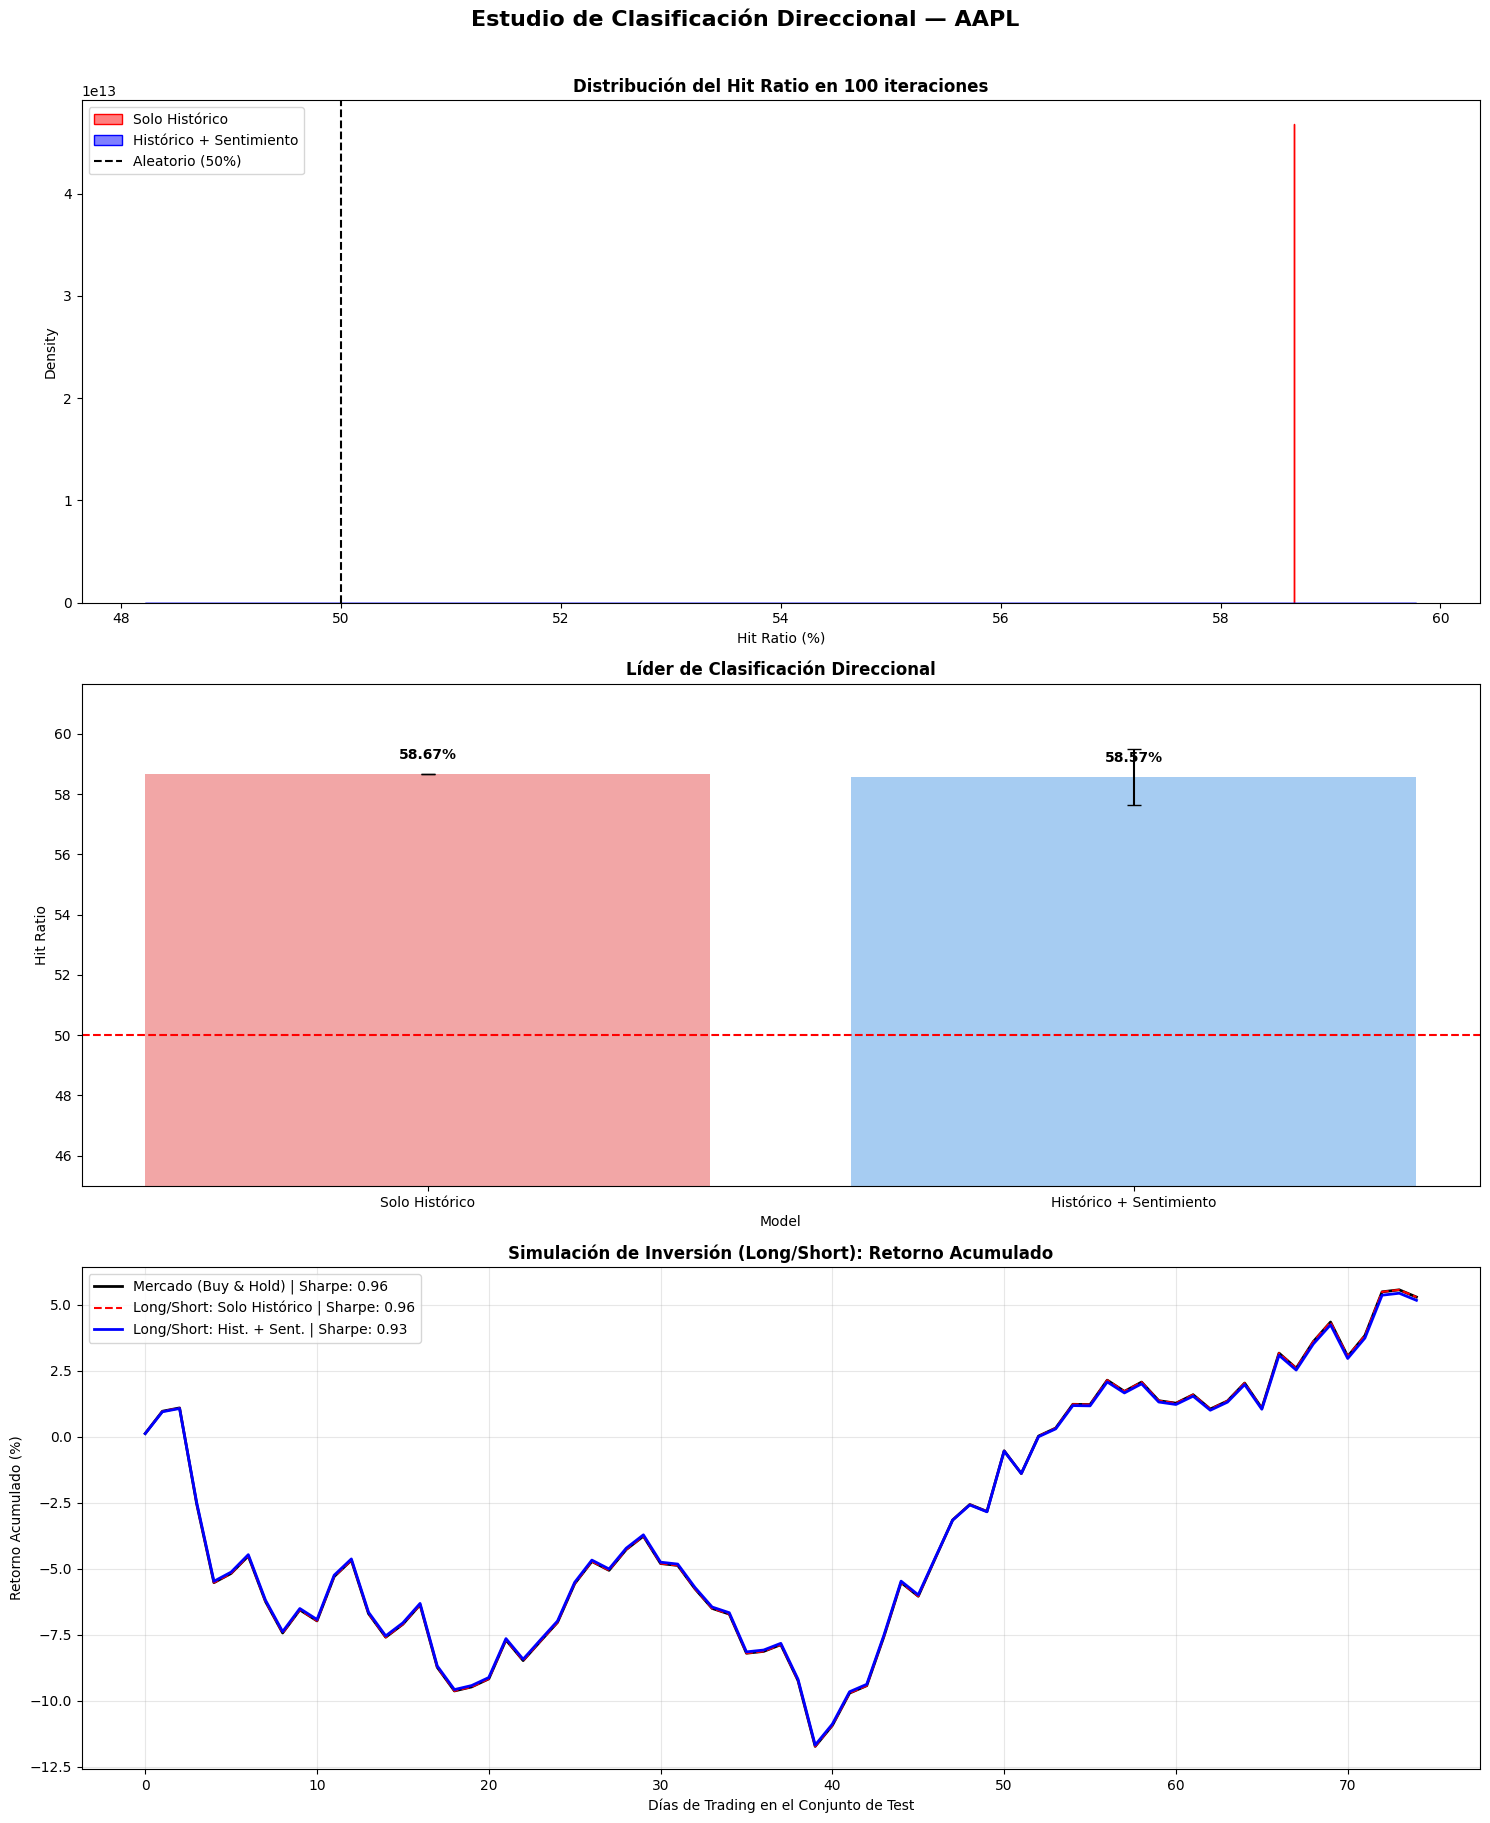

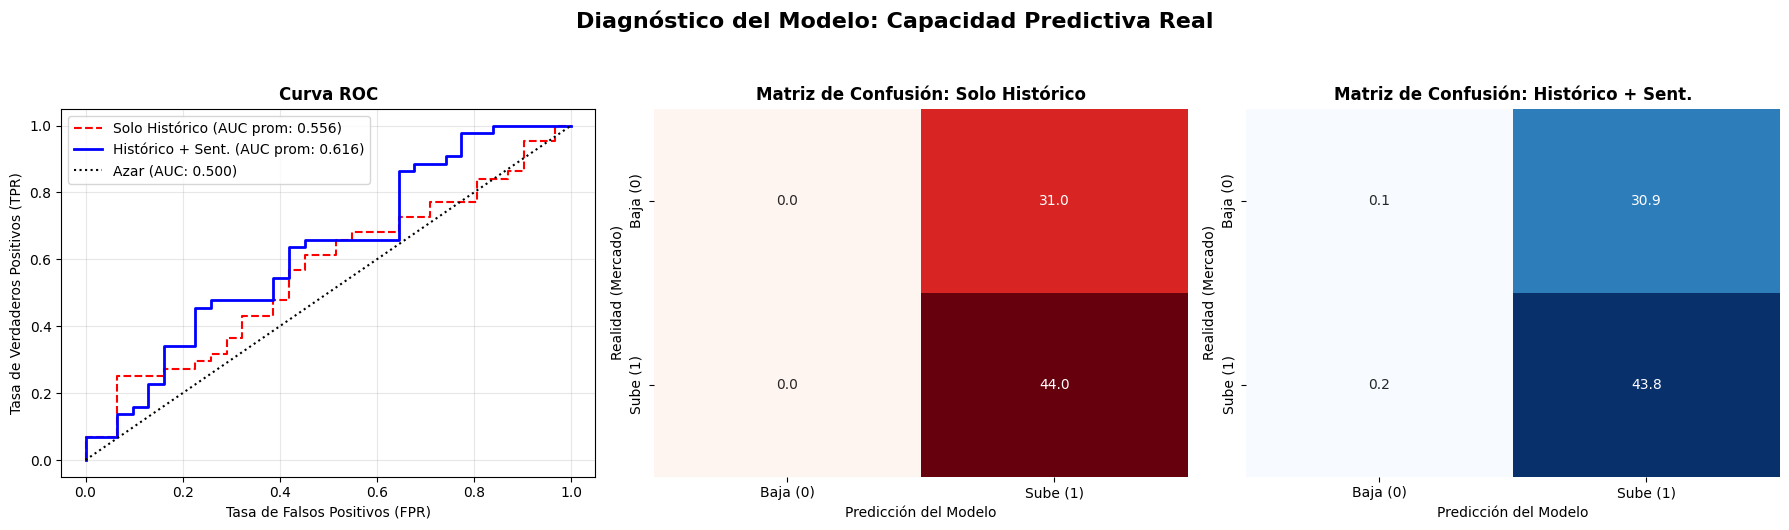

In [ ]:
RUTA_2 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_2,
    n_runs=100,
    window_size=15
)

### NVIDIA, Ventana = 30, lambda = 0.1 y FinnMultiTIME

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA NVDA
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 25m 20s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.84% |     54.55% |     96.83% |     69.78%
Multivariante (Hist + Sent)  |     44.89% |     39.10% |      9.14% |     13.06%

RESUMEN DE MÉTRICAS FI

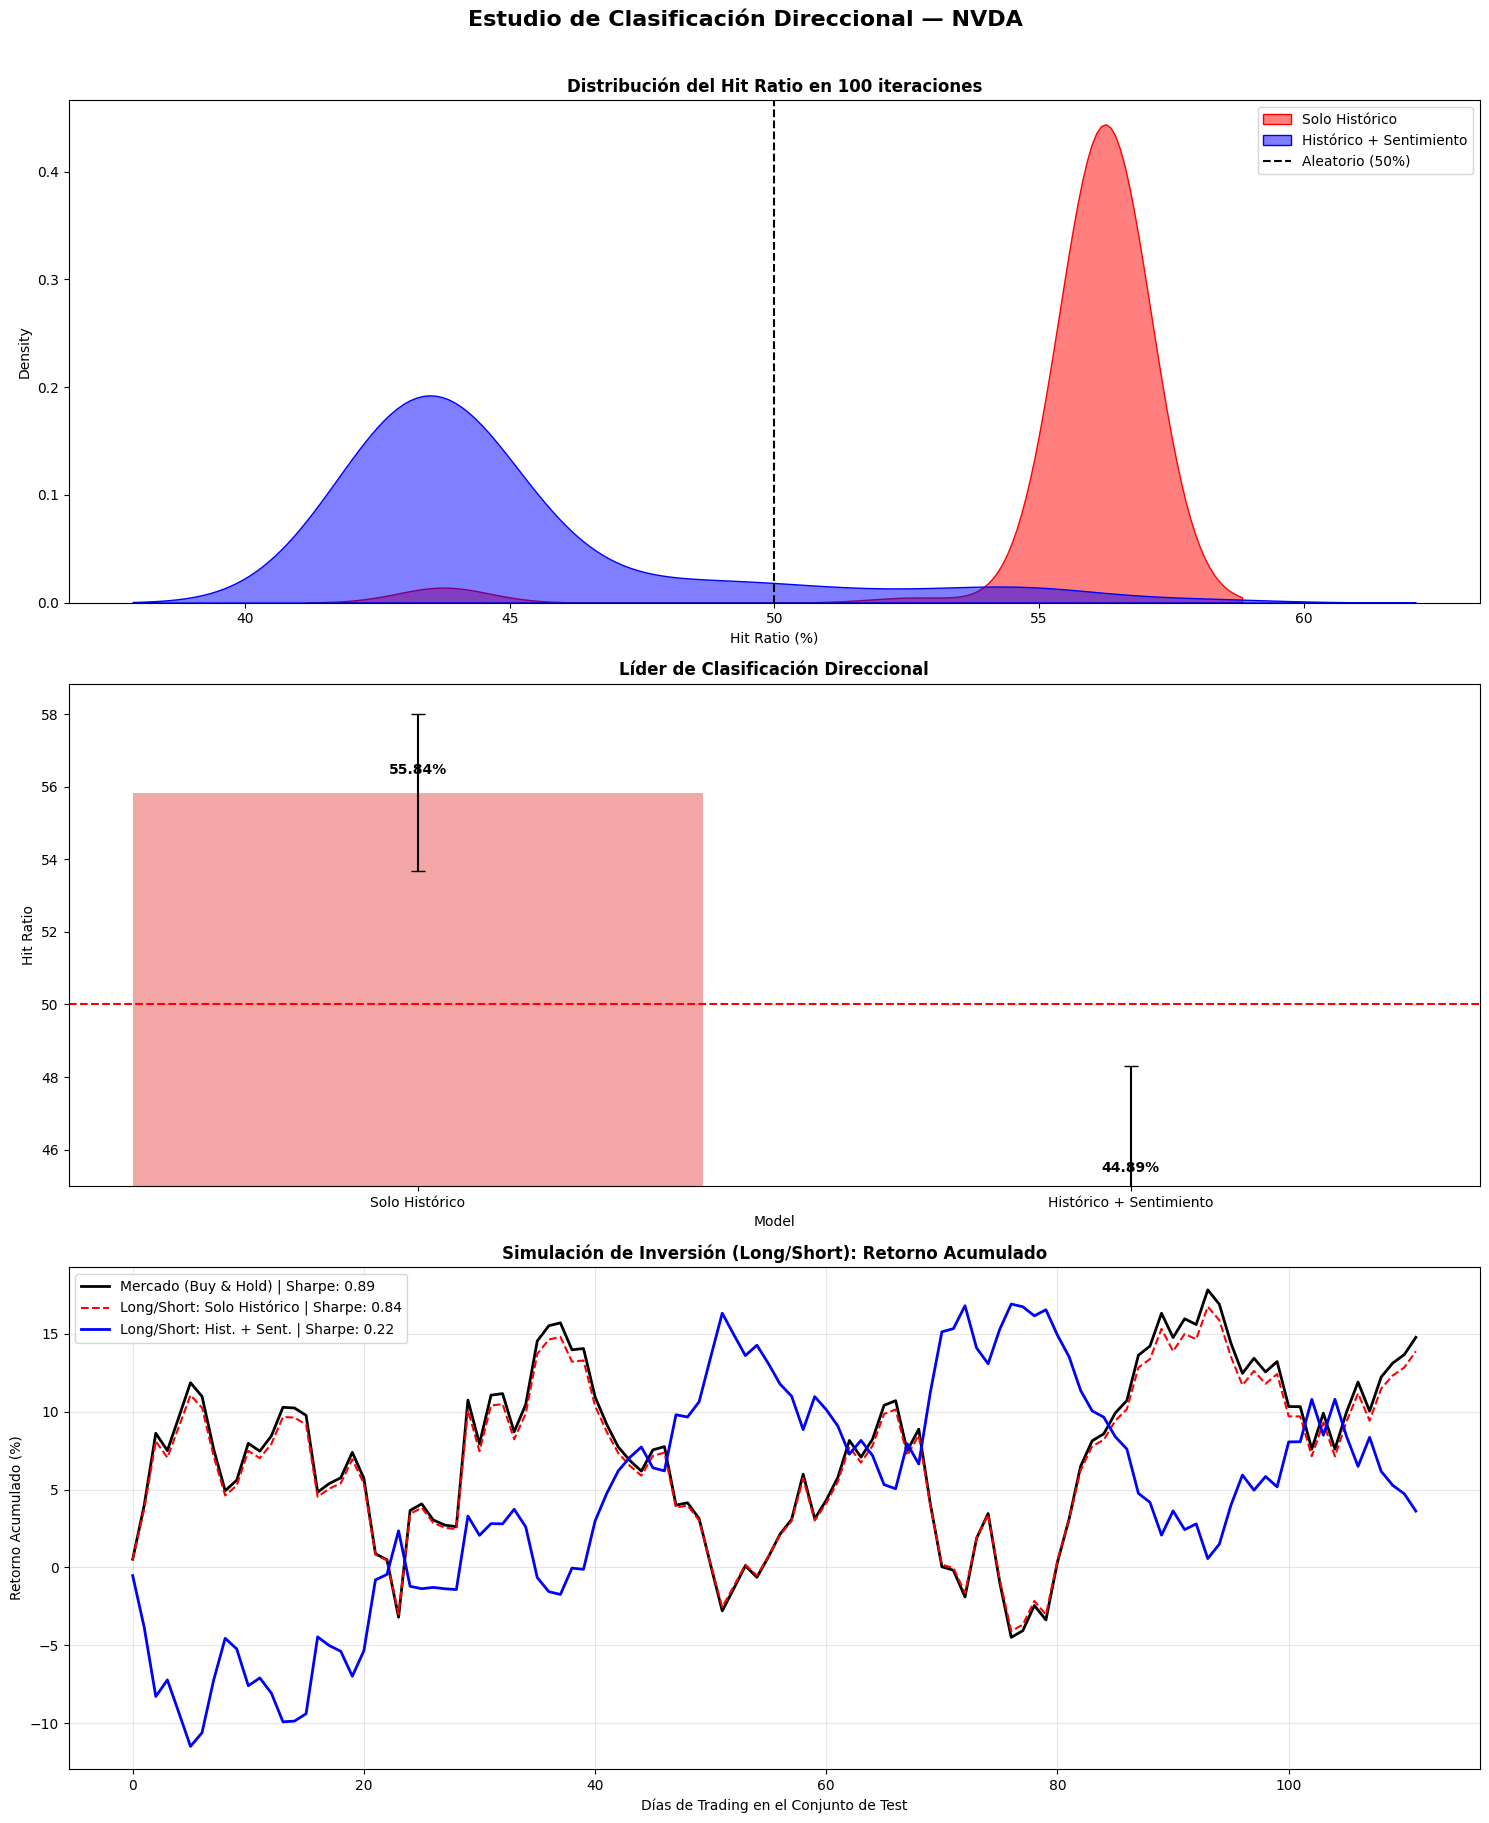

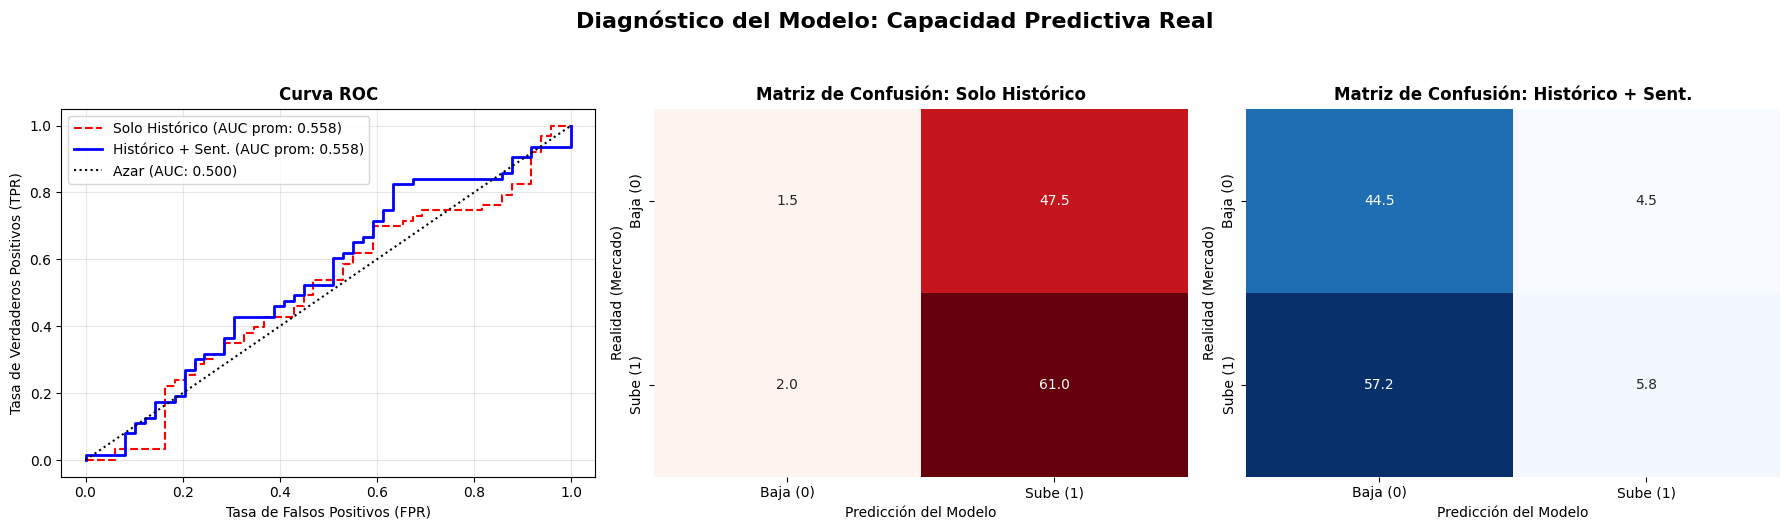

In [ ]:
RUTA_4 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM_lam01.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="NVDA",
    ruta_sentimiento=RUTA_4,
    n_runs=100,
    window_size=30
)

### APPLE, Ventana 15, lambda = 0.03, FNSPID

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 19m 44s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     58.67% |     58.67% |    100.00% |     73.95%
Multivariante (Hist + Sent)  |     51.40% |     56.00% |     71.11% |     61.15%

RESUMEN DE MÉTRICAS FI

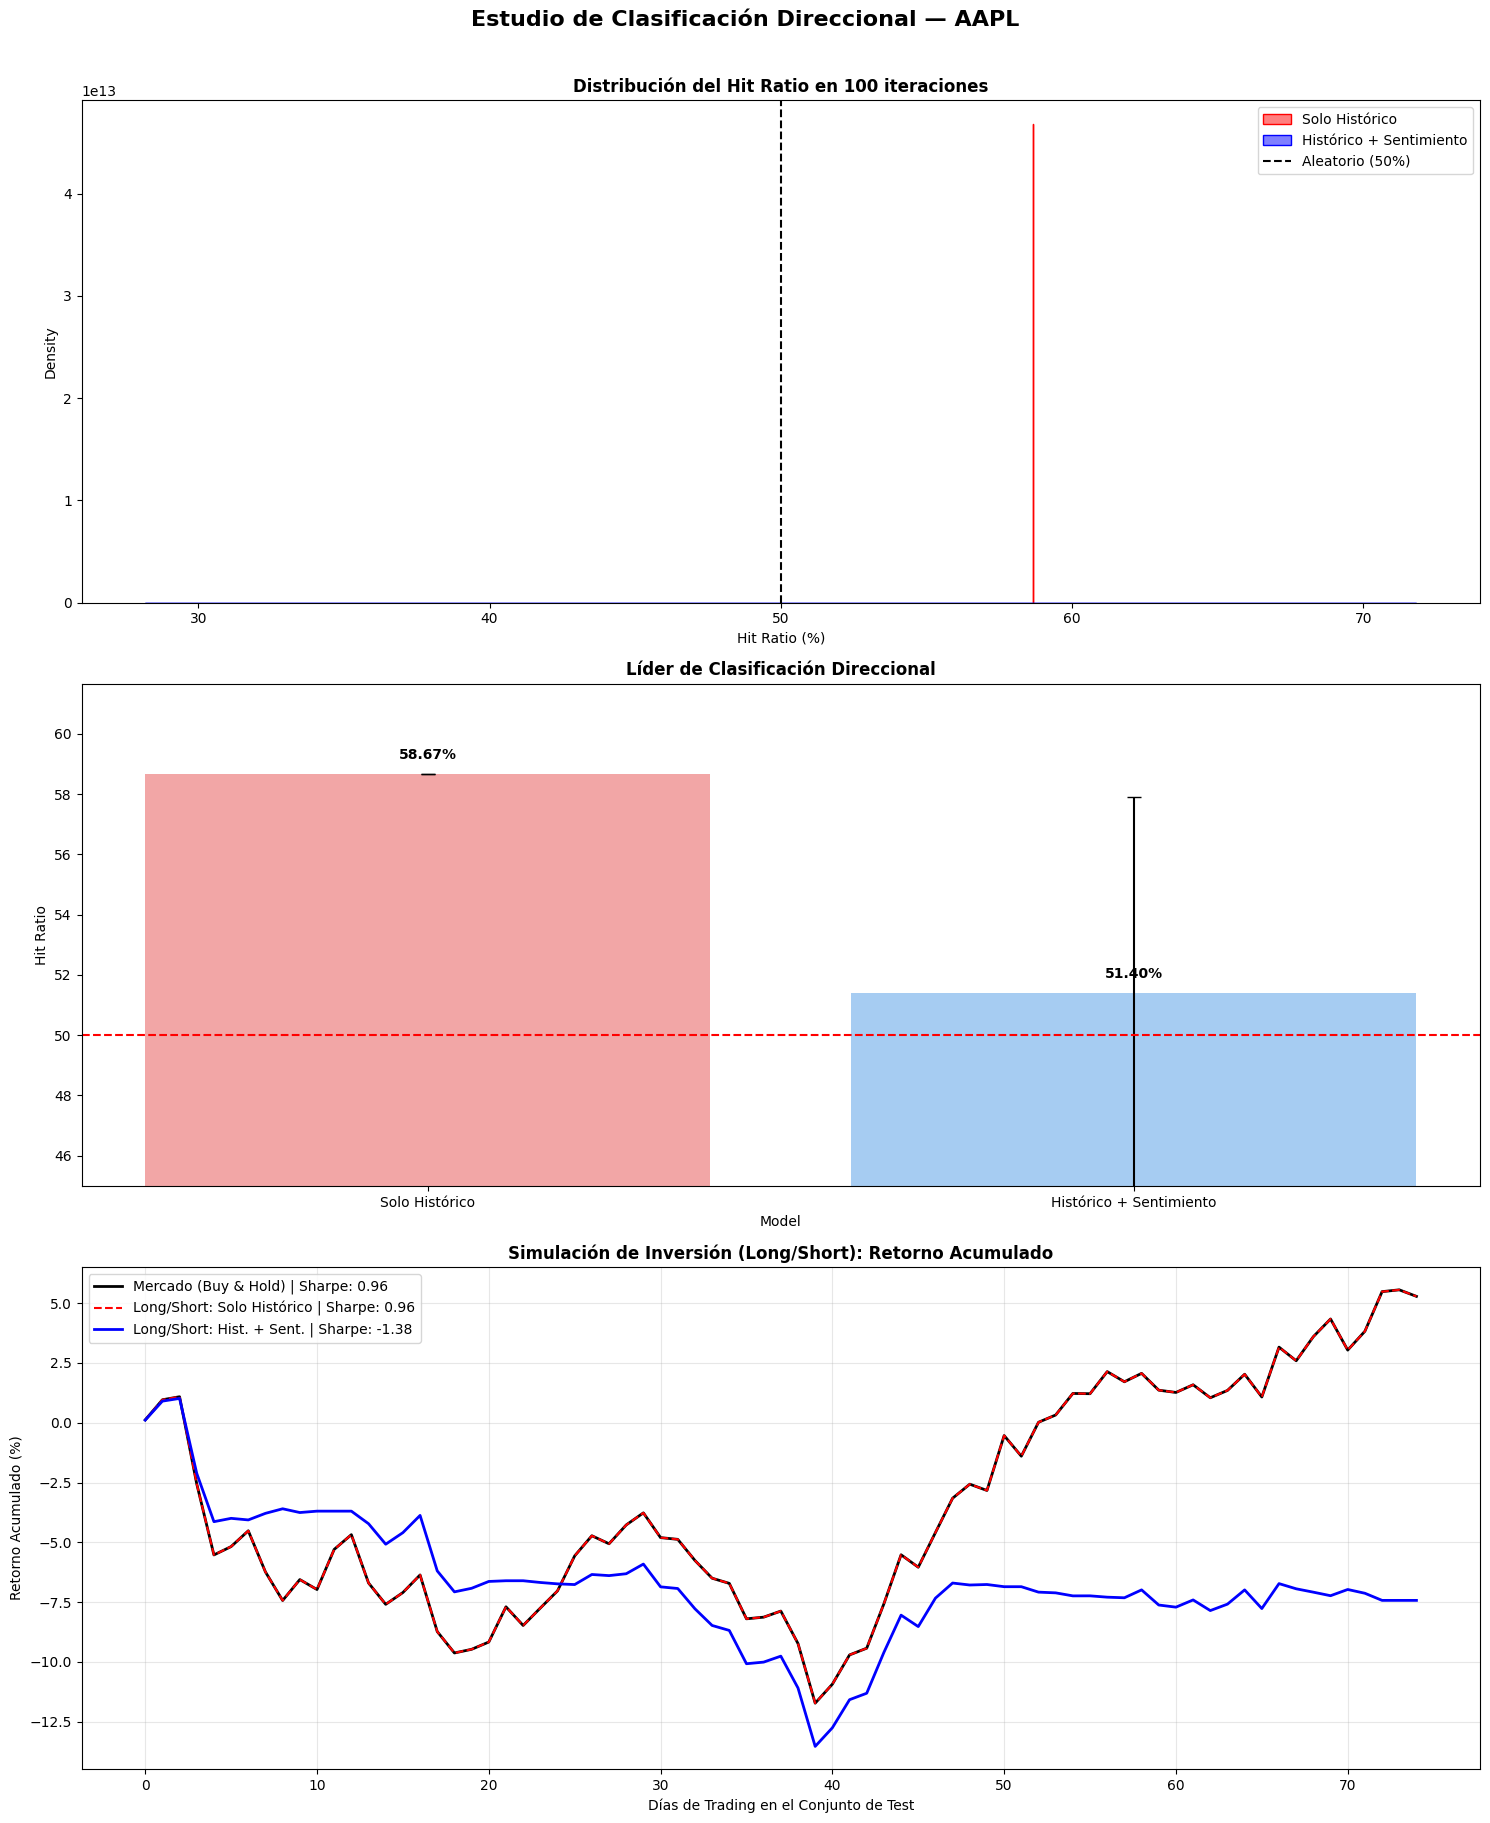

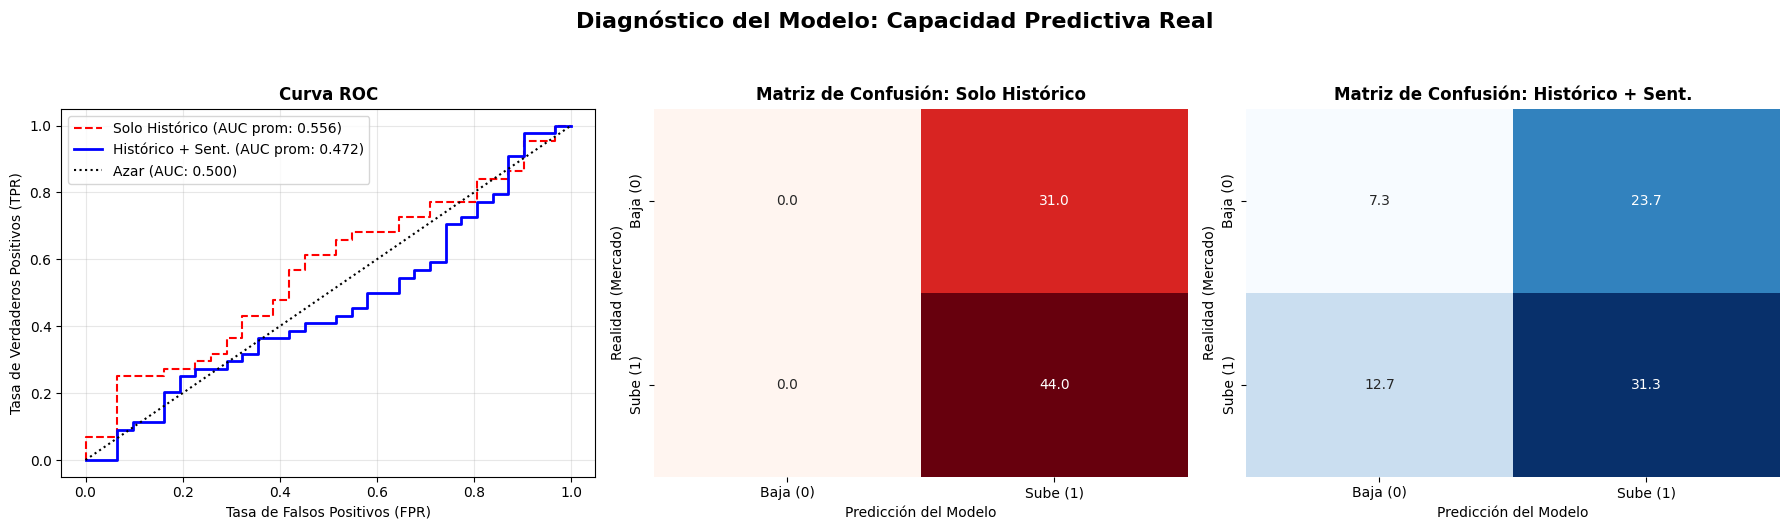

In [ ]:
RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_SENTIMIENTO,
    n_runs=100,
    window_size=15
)

### NVIDIA, Ventana = 30, lambda = 0.1, FNSPID

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA NVDA
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 27m 55s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.84% |     54.55% |     96.83% |     69.78%
Multivariante (Hist + Sent)  |     54.44% |     58.50% |     60.21% |     57.37%

RESUMEN DE MÉTRICAS FI

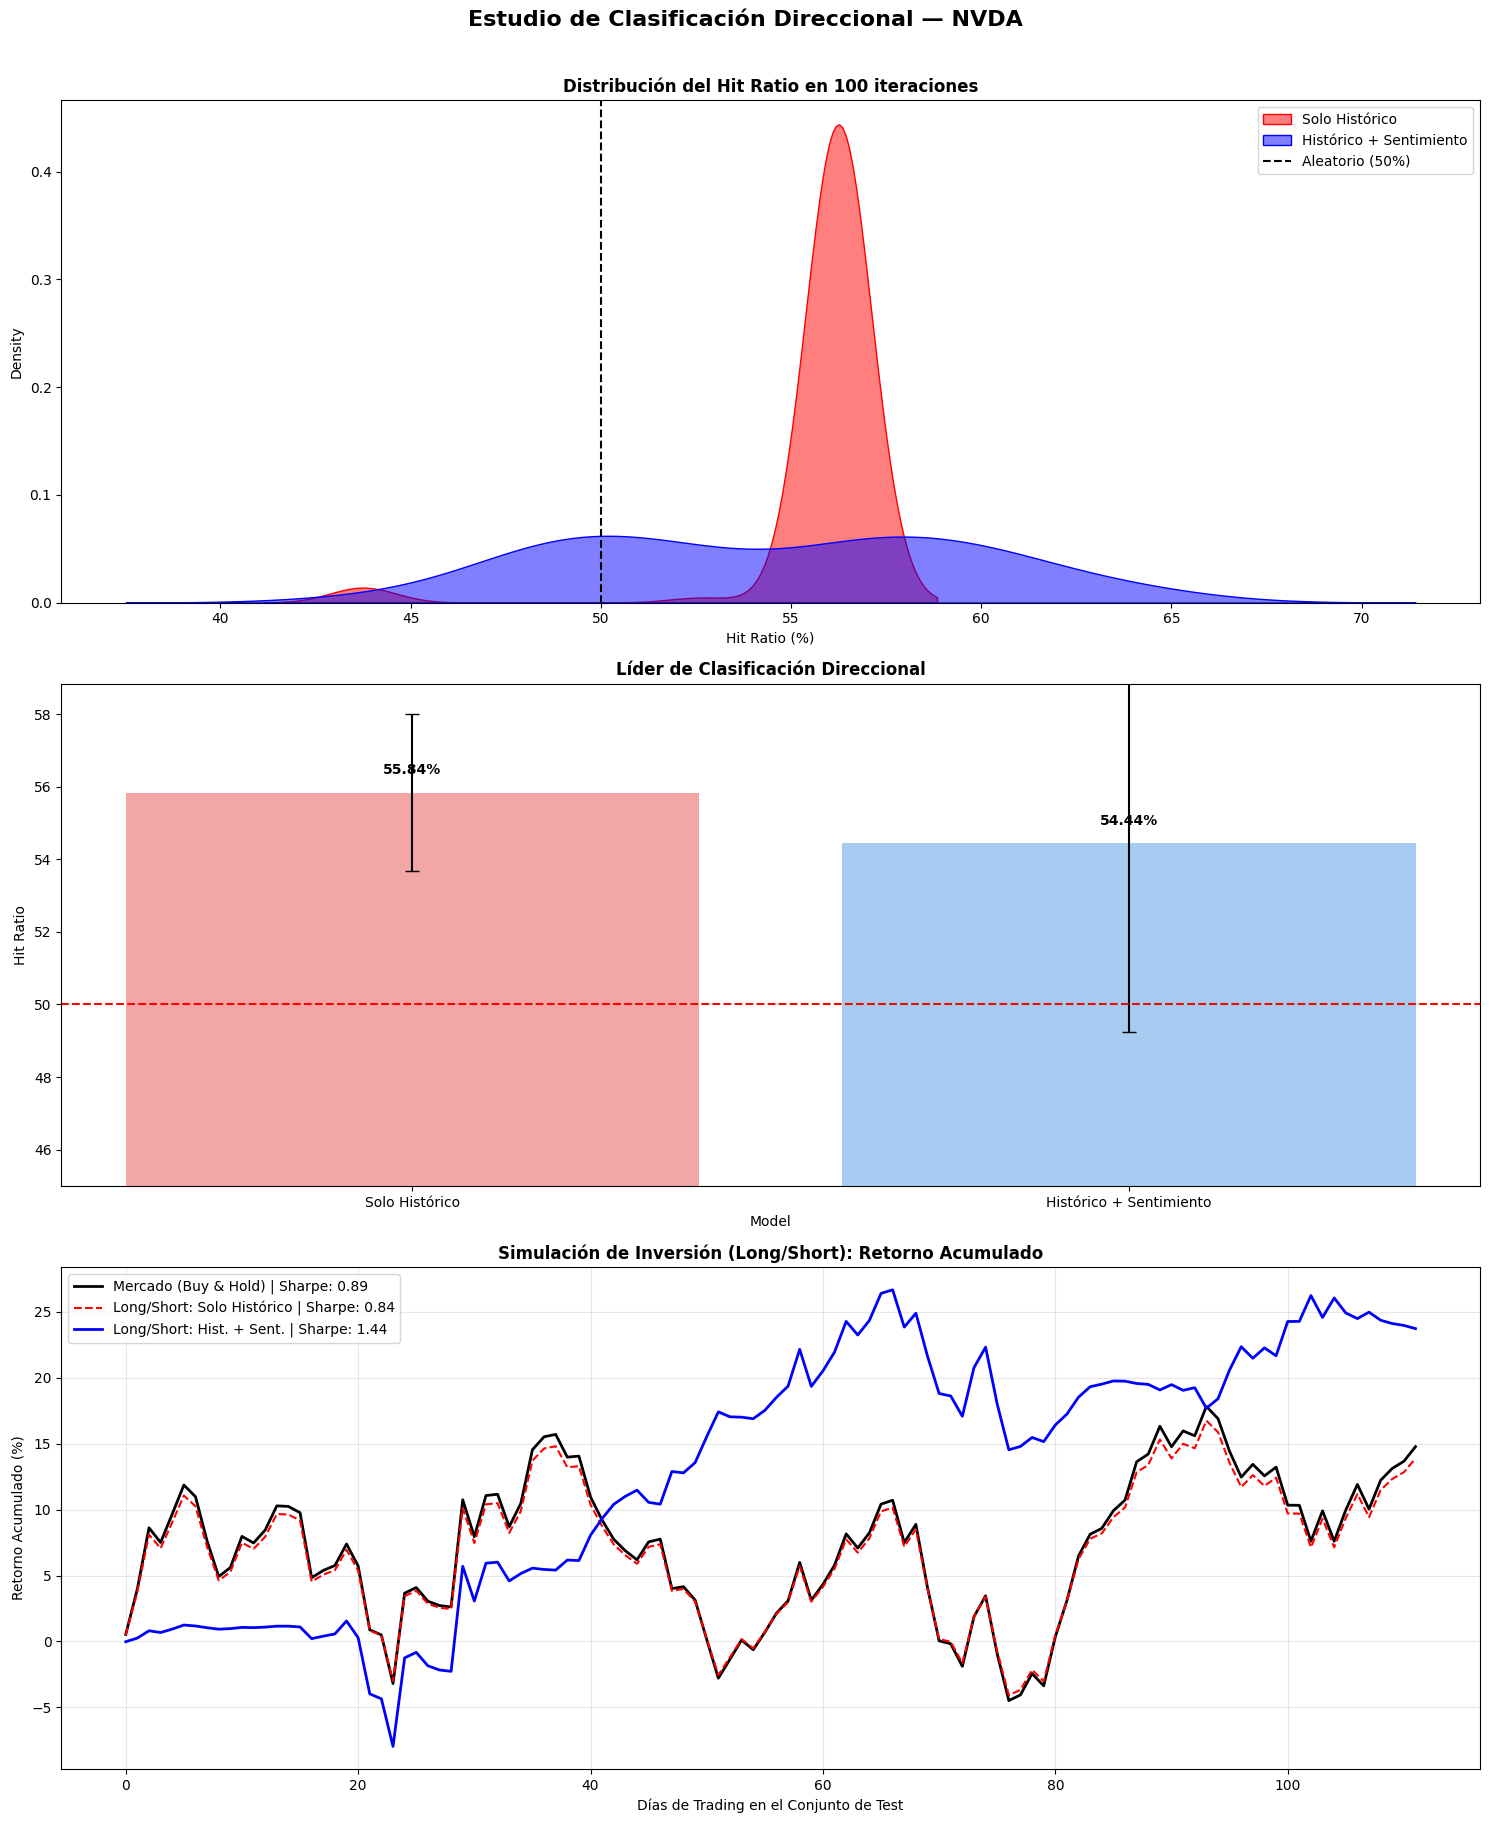

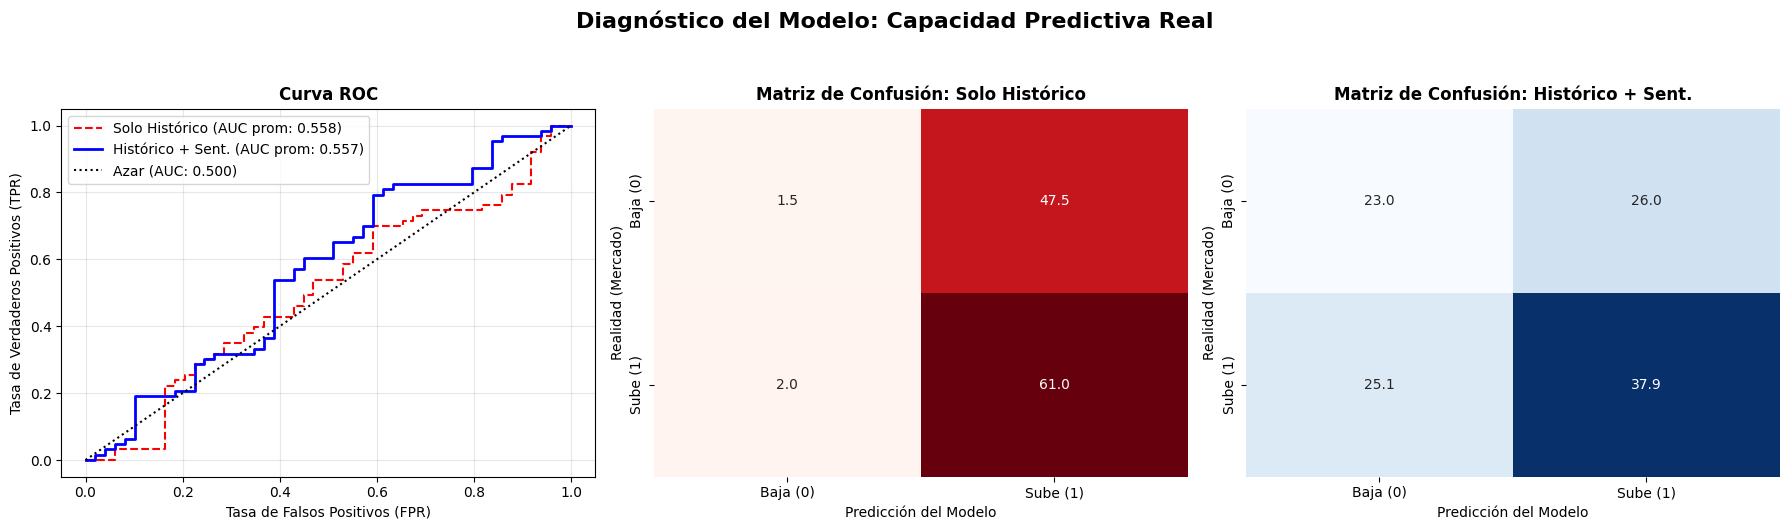

In [ ]:
RUTA_3 = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM_lam01.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="NVDA",
    ruta_sentimiento=RUTA_3,
    n_runs=100,
    window_size=30
)

## Optimización de ventana y lambda para FNSPID (Grid Search)


- APPLE


ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA AAPL
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


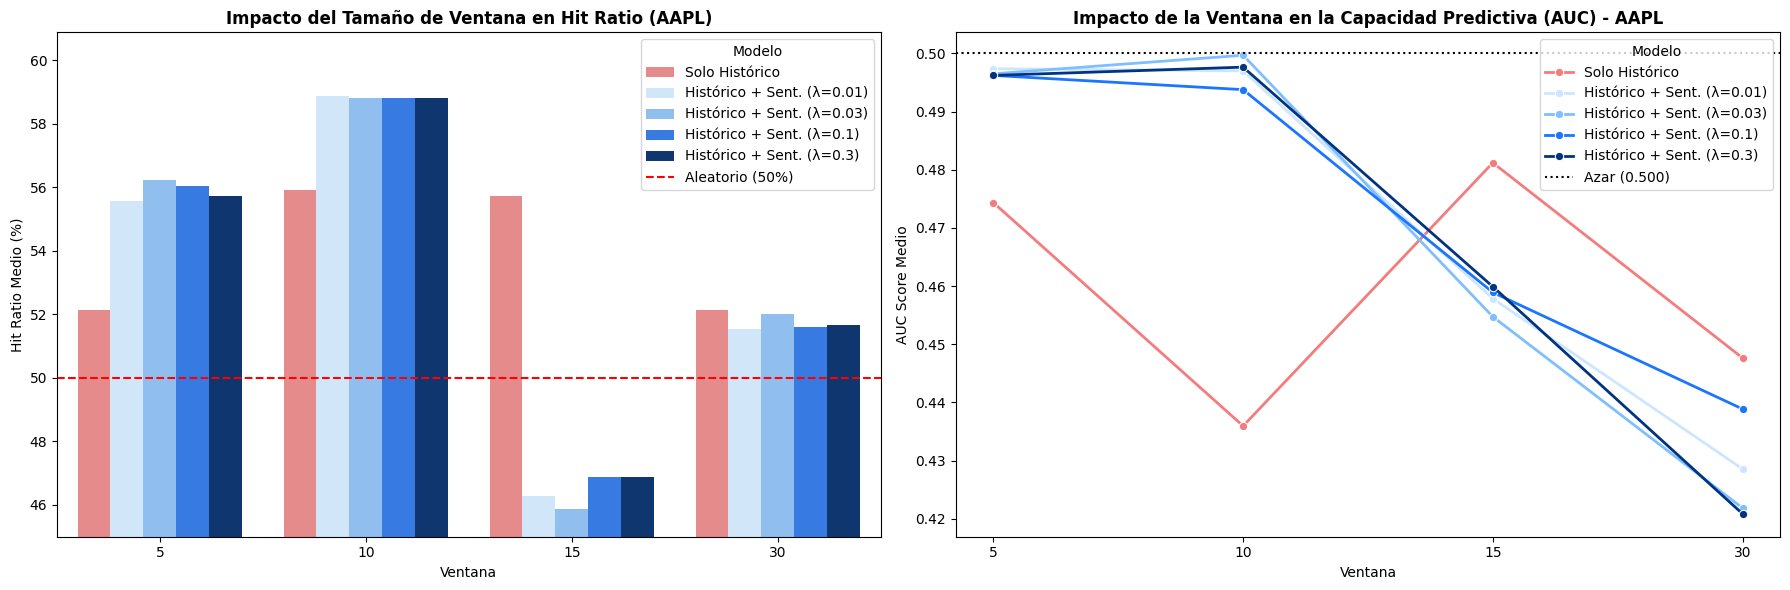

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='AAPL',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

- NVIDIA

ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA NVDA
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


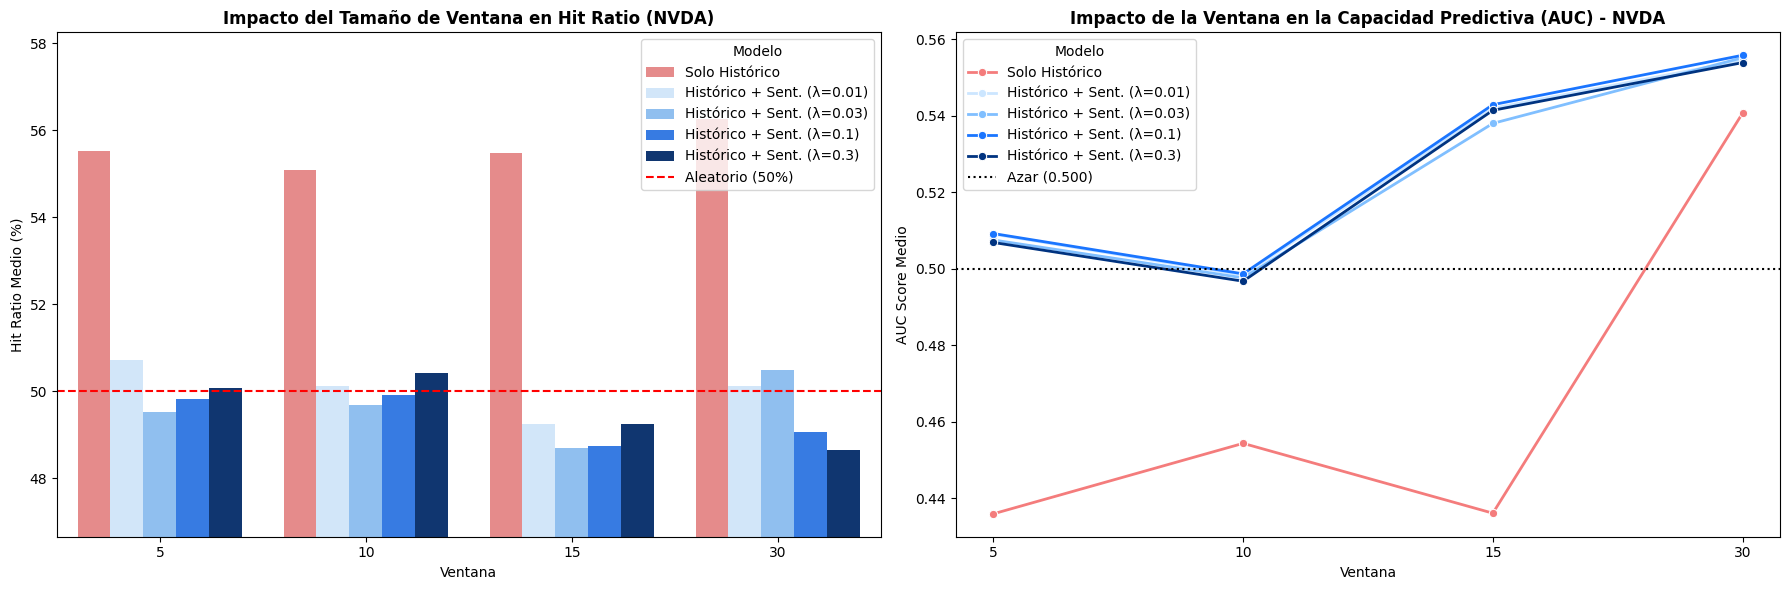

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='NVDA',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

- ORACLE

ANÁLISIS DE CLASIFICACIÓN: VENTANAS Y DECAIMIENTO PARA ORCL
--- Evaluando Tamaño de Ventana: 5 días ---
--- Evaluando Tamaño de Ventana: 10 días ---
--- Evaluando Tamaño de Ventana: 15 días ---
--- Evaluando Tamaño de Ventana: 30 días ---


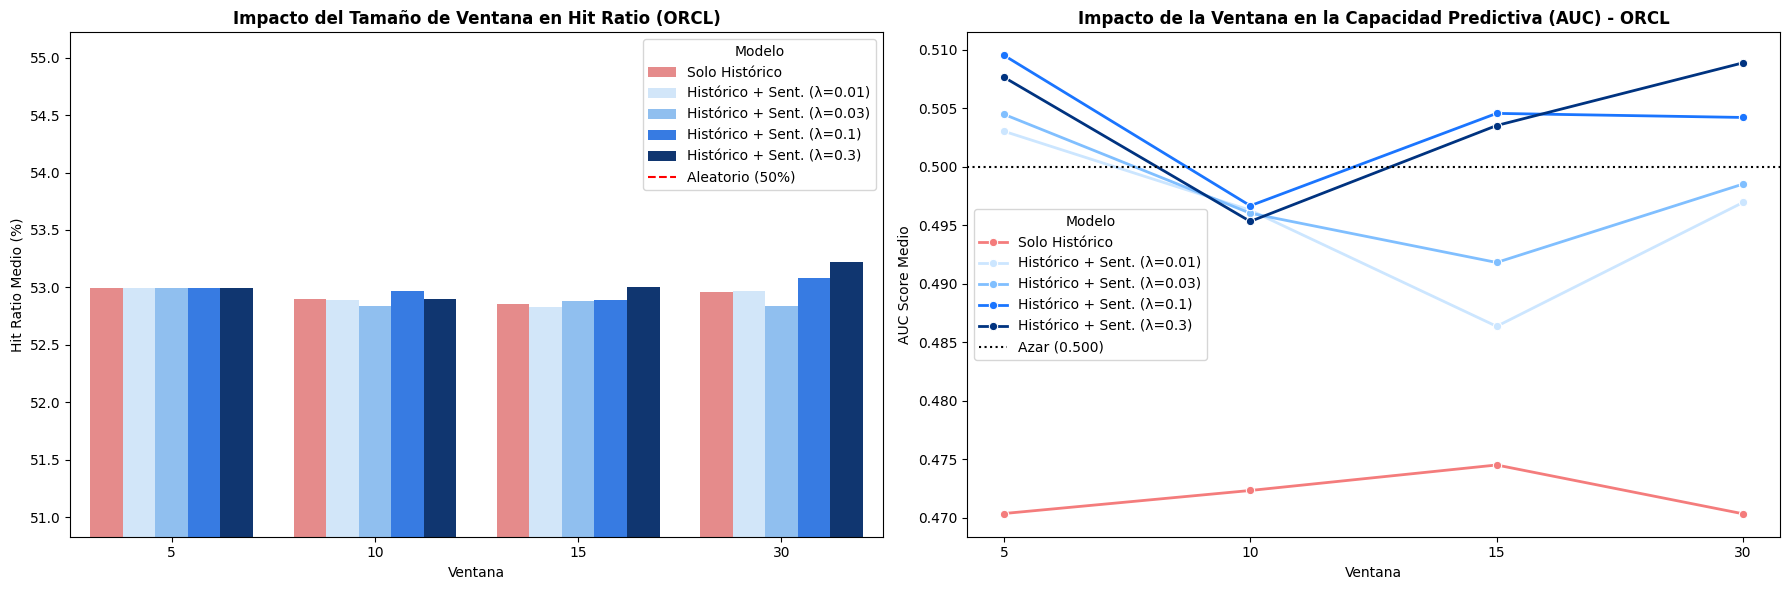

In [ ]:
resultados = experimento_ventanas_y_lambdas(
    ticker='ORCL',
    ruta_sentimiento = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet',
    ventanas=[5, 10, 15, 30],
    lambdas=[0.01, 0.03, 0.10, 0.30],
    n_runs=20
)

### Oracle, FNSPID, Ventana = 5 y lambda = 0.03

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA ORCL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 44m 3s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     52.99% |     52.99% |    100.00% |     69.27%
Multivariante (Hist + Sent)  |     52.48% |     52.80% |     94.16% |     66.53%

RESUMEN DE MÉTRICAS FIN

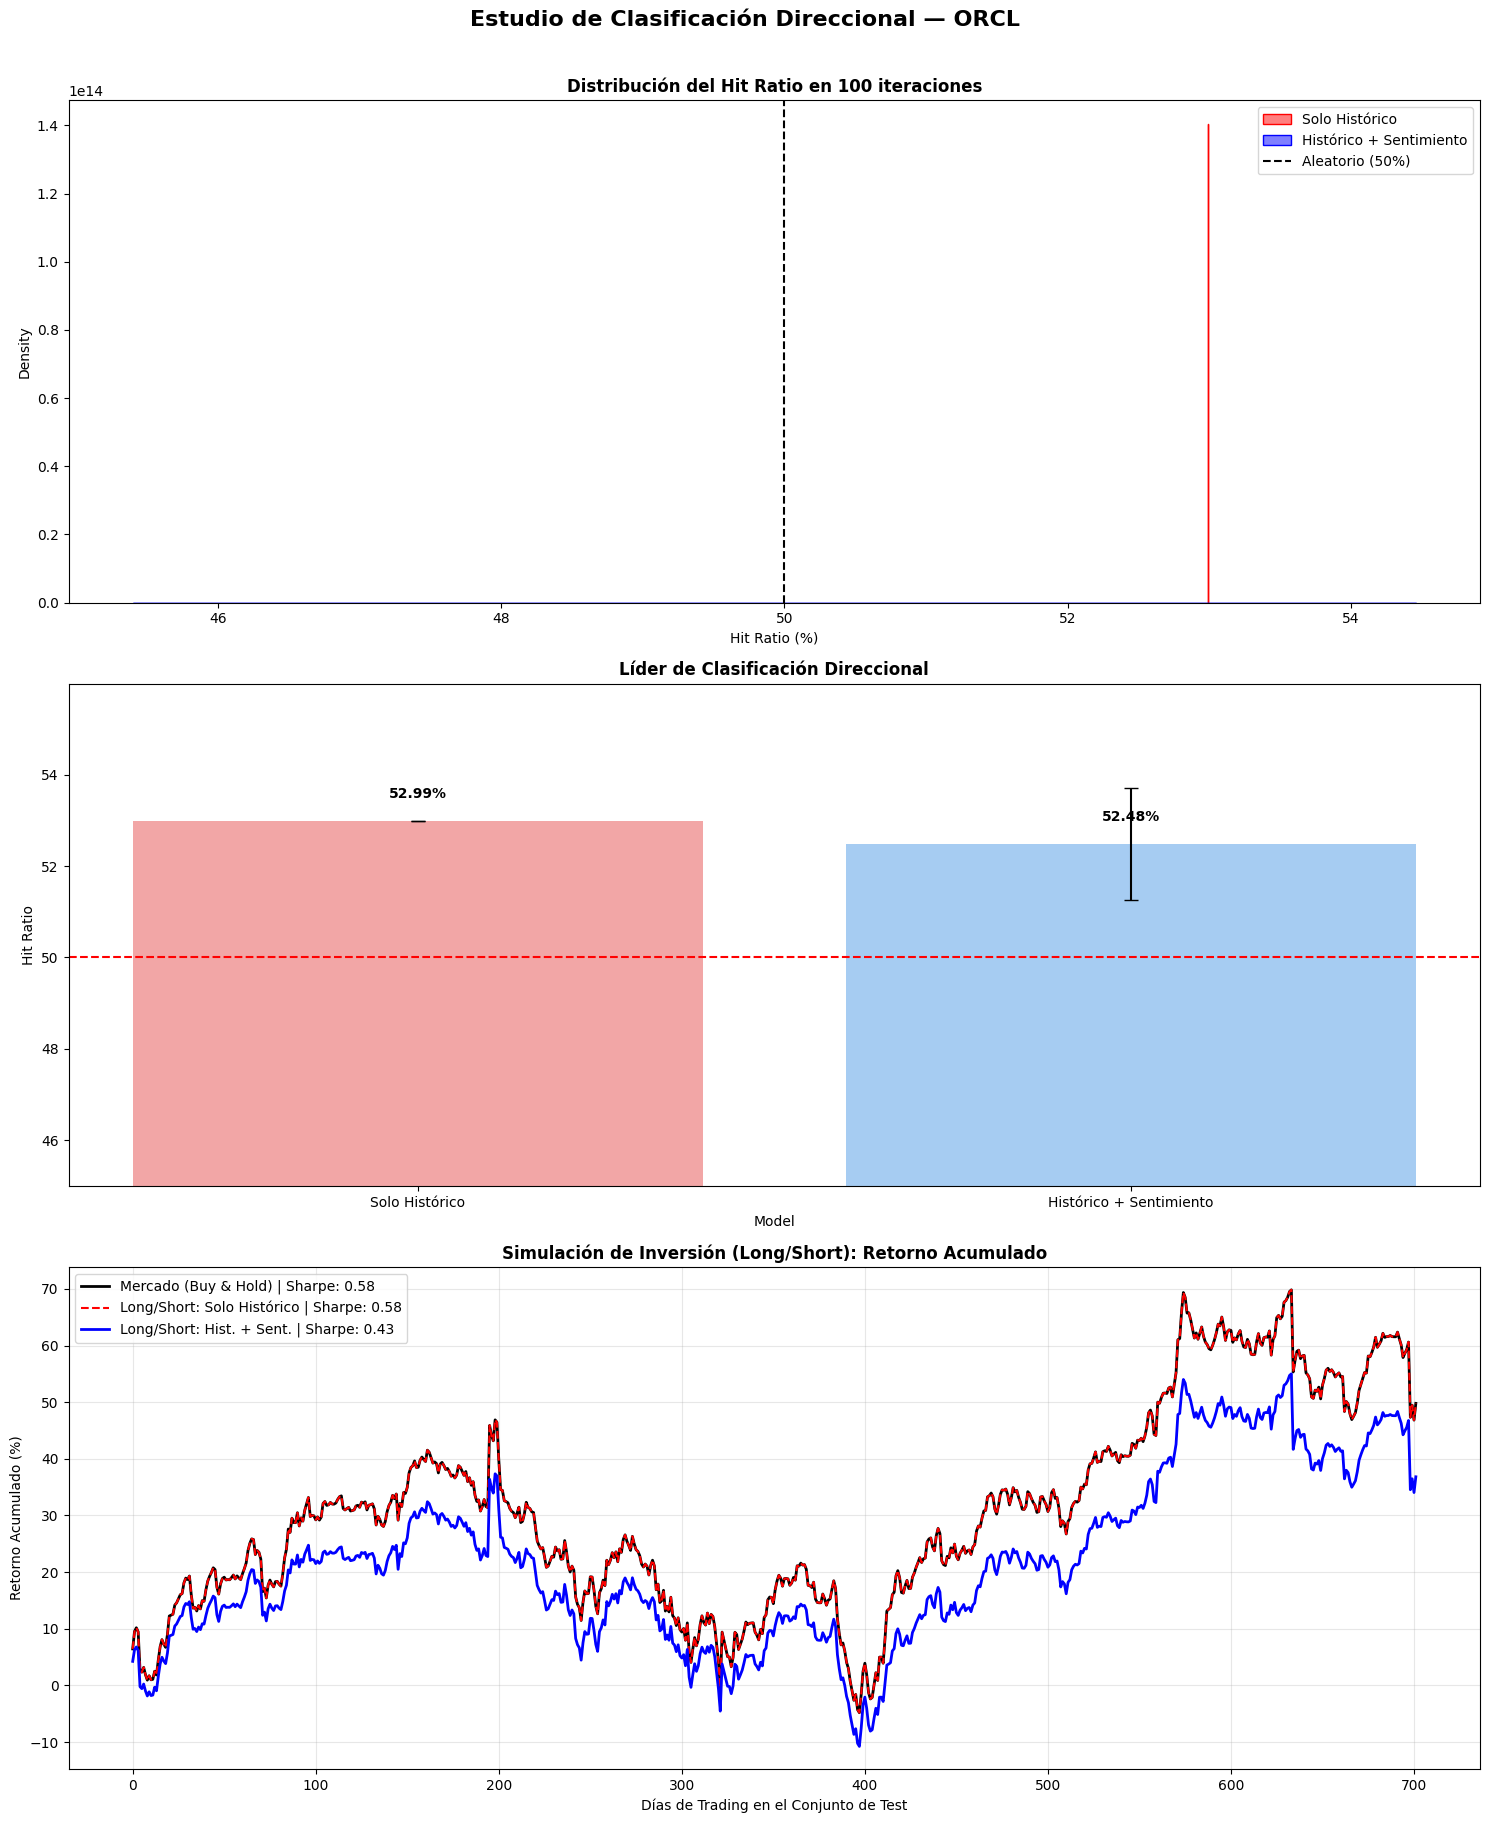

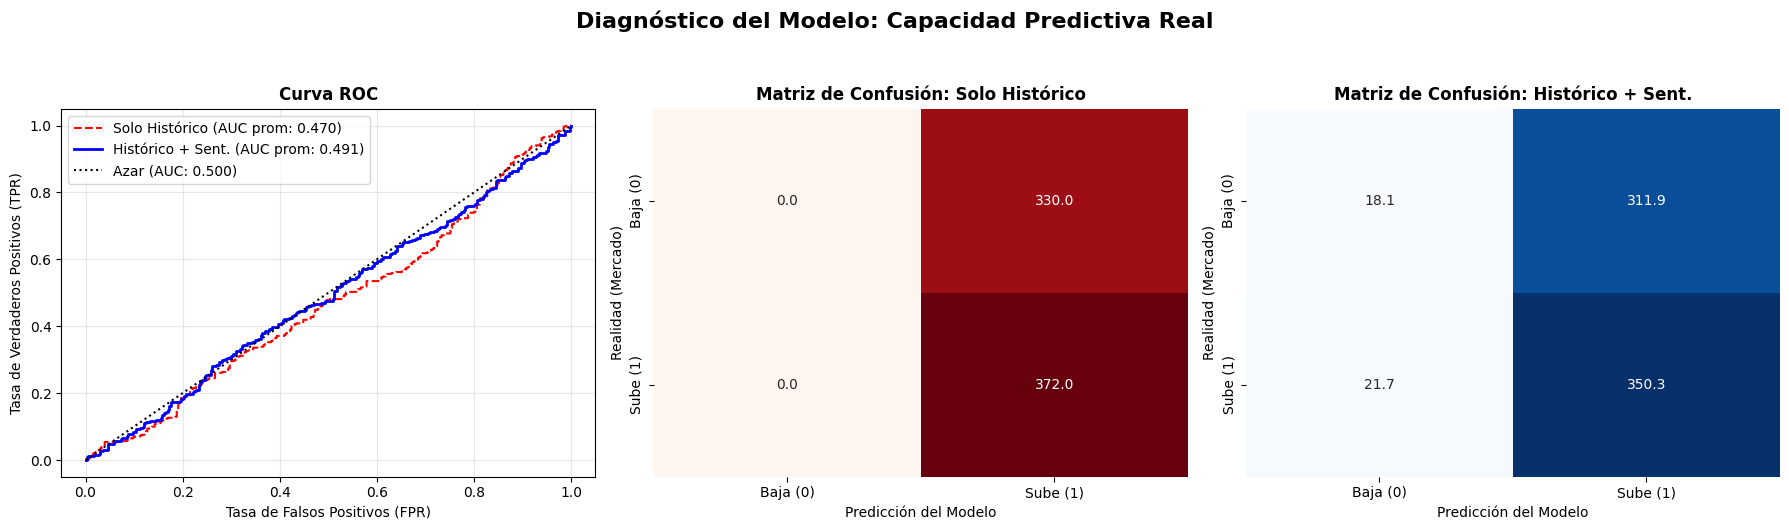

In [ ]:
RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="ORCL",
    ruta_sentimiento=RUTA_SENTIMIENTO,
    n_runs=100,
    window_size=5
)

### Oracle, FinMultiTime, Ventana = 5 y lambda = 0.03

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA ORCL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 61m 2s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     52.99% |     52.99% |    100.00% |     69.27%
Multivariante (Hist + Sent)  |     52.80% |     52.51% |     95.45% |     67.34%

RESUMEN DE MÉTRICAS FIN

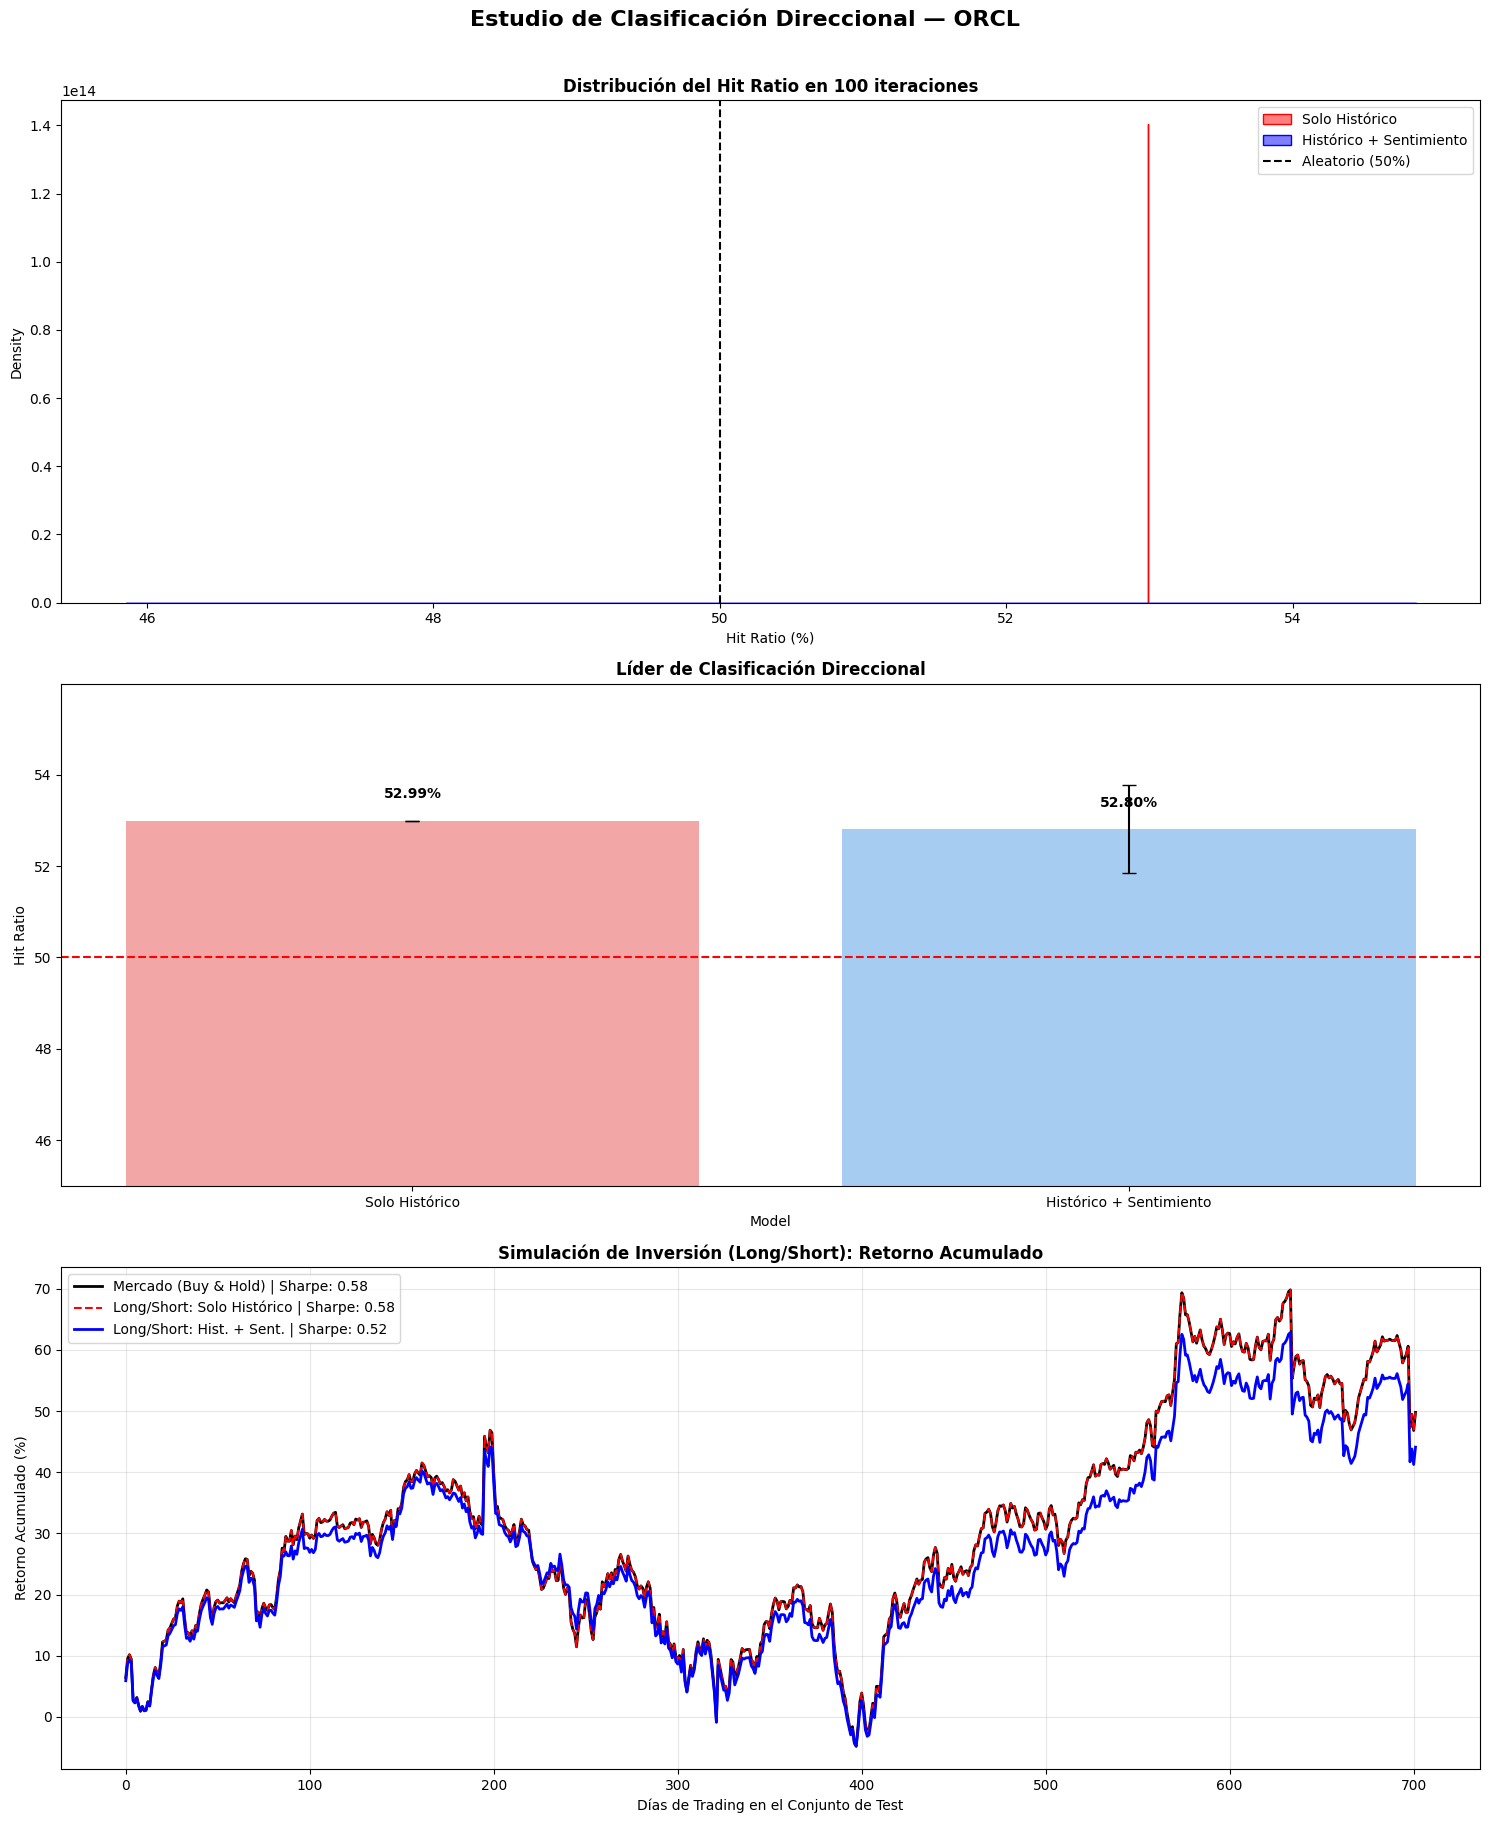

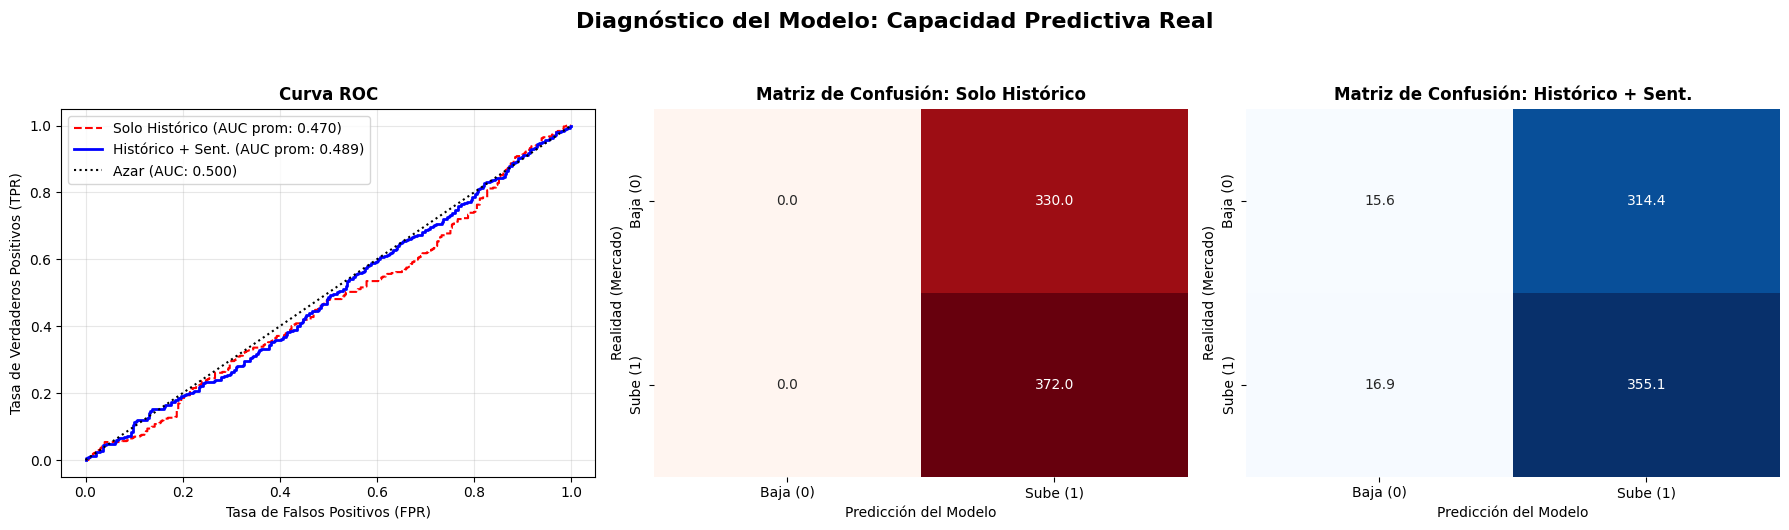

In [ ]:
RUTA_2 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="ORCL",
    ruta_sentimiento=RUTA_2,
    n_runs=100,
    window_size=5
)